<img src="https://res.cloudinary.com/dtizipxds/image/upload/q_auto/f_auto/v1776264397/banner_yvwajv.png" width="100%">


In [ ]:
%pip install -r ../requirements.txt


## Project Overview

This notebook presents a comprehensive data mining analysis of the Algerian laptop market dataset. The primary objective is to **understand the data, discover patterns, and extract actionable business insights** for both buyers and sellers.

### Methodology (CRISP-DM aligned)

| Phase | Content |
|-------|---------|
| **1** | Business Understanding — objectives for buyers and sellers |
| **2** | **Data Understanding** (this notebook) — load data, assess quality, EDA |
| **3** | Data Preparation — price cleaning, feature engineering |
| **4** | Modeling — train/test split, baseline models, regression |
| **5** | Evaluation — metrics, diagnostics, learning curves |
| **6** | Deployment — recommendations, pricing tool |

---

## Phase 1: Business Understanding

### Business Objectives

#### For Buyers:
1. **Value Maximization**: Find the best laptop configuration (CPU, GPU, RAM) for a given budget bracket (e.g., <80k, 80k–150k, >150k DZD)
2. **Price Optimization**: Identify fair market prices and quantify how much overpaying occurs (e.g., listings >20% above segment median)
3. **Feature Prioritization**: Understand which features justify premium pricing (e.g., +X% for High GPU vs None, +Y% for DDR5 vs DDR4)
4. **Condition Assessment**: Quantify the discount for used ("BON ÉTAT") vs. new ("JAMAIS UTILISÉ") laptops in % terms
5. **Timing Strategy**: Identify best months to buy (e.g., avoid back-to-school peaks in Aug–Oct when median prices may be higher)

#### For Sellers:
1. **Competitive Pricing**: Price laptops within ±10% of segment median to maximize sale probability
2. **Feature Highlighting**: Identify which features command the highest premiums (GPU tier, condition, brand) to emphasize in listings
3. **Condition Pricing**: Apply appropriate depreciation for used items (quantify "BON ÉTAT" discount vs "JAMAIS UTILISÉ")
4. **Timing Strategy**: Know when listing volume peaks (Aug–Oct) and whether median price rises or falls with volume
5. **Brand Positioning**: Understand brand premiums (e.g., Apple vs HP vs Lenovo for similar specs) to set competitive prices

#### For the Platform:
1. **Data Quality**: Flag and correct price anomalies (missing zeros, centimes errors) to improve user trust
2. **Segment Insights**: Provide median price ranges per segment (CPU class × GPU class × condition) for price guidance
3. **Market Trends**: Track temporal patterns (year-over-year volume, seasonal peaks) to inform marketing

**This notebook** supports these by exploring the preprocessed data to answer "what drives price?" and "when/where do listings concentrate?" with clear, quantified takeaways per plot.

---

### Notebook  Overview
This notebook performs comprehensive exploratory data analysis on the preprocessed laptop market data:
1. **Setup** — Load preprocessed data
2. **Data Quality & Profile** — Missing values, duplicates, univariate profile, price/skewness
3. **Temporal Patterns** — Listing volume and median price by month/year
4. **Price Distributions** — By CPU, GPU, condition, RAM, resolution, screen frequency
5. **Market Segmentation** — K-Means clustering on configuration (no price)
6. **Feature Correlation** — Spearman & Cramér's V with price; correlation heatmap (incl. PassMark); PassMark vs price scatter
7. **Brand Analysis** — Market share and median price by brand
8. **Wilaya Distribution** — Geographic distribution of listings
9. **Summary & Market Insights** — Key statistics and recommendations

**Prerequisites**: Run `01_Preprocessing.ipynb` first to generate `data_preprocessed.csv`

---
## 1. Setup and Load Data

In [1]:
# ============================================================================
# IMPORTS AND CONFIGURATION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import scipy.stats as ss

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f" EDA started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

All libraries imported successfully!
 EDA started at: 2026-02-08 16:14:02


In [2]:
# Load preprocessed data
df_clean = pd.read_csv('../data/data_preprocessed.csv')
df_clean['created_at'] = pd.to_datetime(df_clean['created_at'], errors='coerce')

print(f"Preprocessed data loaded!")
print(f" Total records: {len(df_clean):,}")
print(f" Total columns: {len(df_clean.columns)}")
print(f" Date range: {df_clean['created_at'].min()} to {df_clean['created_at'].max()}")

Preprocessed data loaded!
 Total records: 16,283
 Total columns: 62
 Date range: 2018-11-27 08:27:31+00:00 to 2025-08-11 16:34:50+00:00


---
## 2. 📊 Data Quality & Profile

Before exploring patterns, we assess **missing values**, **duplicates**, and **distributions** of key columns. This helps interpret later plots and justifies choices (e.g. log scale for price in regression).

1. MISSING VALUES (columns with at least one missing):
               Column  Missing  Missing %
           gpu_suffix    15982      98.15
  screen_frequency_Hz    15233      93.55
     SCREEN_FREQUENCY    15233      93.55
             HDD_SIZE    15123      92.88
          HDD_SIZE_GB    15123      92.88
gpu_performance_class    13561      83.28
        DEDICATED_GPU    12622      77.52
             RAM_TYPE    10969      67.36
        screen_pixels    10188      62.57
             screen_h    10188      62.57
             screen_w    10188      62.57
    SCREEN_RESOLUTION    10174      62.48
            spec_Etat     6746      41.43
           cpu_suffix     4245      26.07
       cpu_generation     2822      17.33
      SCREEN_SIZE_NUM     2165      13.30
          SCREEN_SIZE     2137      13.12
          SSD_SIZE_GB     1898      11.66
             SSD_SIZE     1897      11.65
    cpu_single_thread     1506       9.25
            cpu_cores     1506       9.25
          cpu_threads

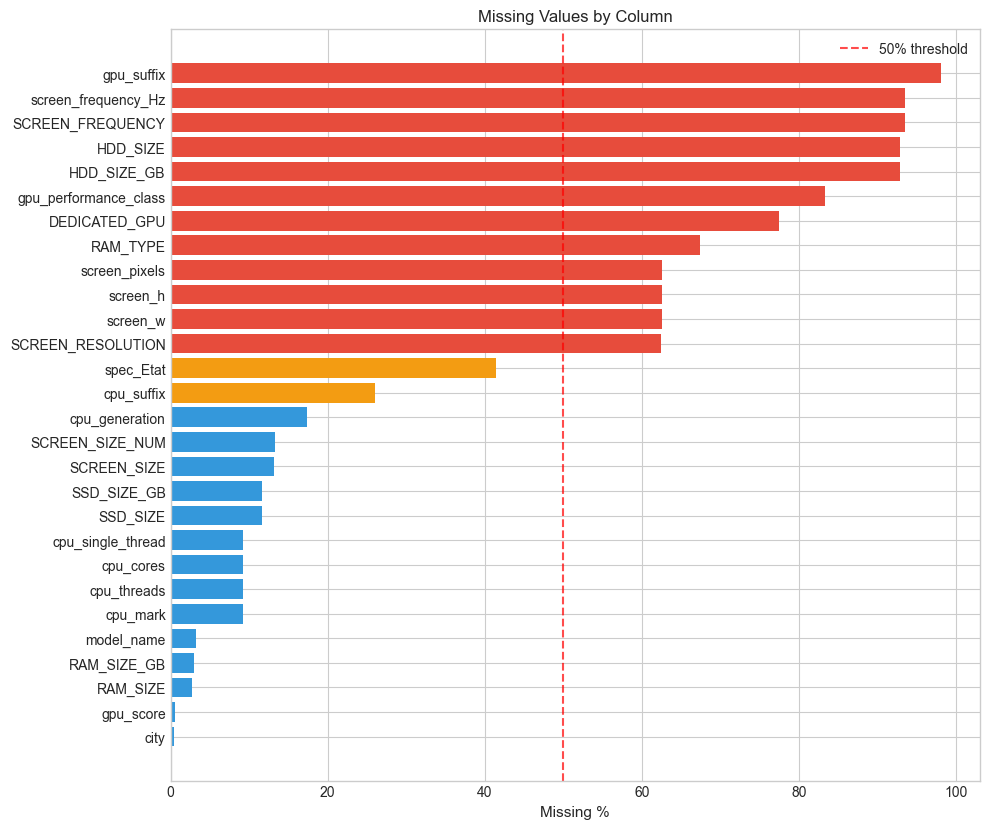

In [3]:
# ============================================================================
# MISSING VALUES & DUPLICATES
# ============================================================================
from scipy.stats import skew
import matplotlib.pyplot as plt
import pandas as pd

missing_df = pd.DataFrame({
    'Column': df_clean.columns,
    'Missing': df_clean.isnull().sum().values,
    'Missing %': (df_clean.isnull().sum().values / len(df_clean) * 100).round(2)
}).sort_values('Missing %', ascending=False)

print("1. MISSING VALUES (columns with at least one missing):")
print(missing_df[missing_df['Missing'] > 0].to_string(index=False))

dup_count = df_clean.duplicated().sum()
print(f"\n2. DUPLICATES: {dup_count} ({dup_count/len(df_clean)*100:.2f}%)")

# Visualize missing values (only columns with missing)
missing_cols = missing_df[missing_df['Missing'] > 0].copy()

plt.figure(figsize=(10, max(6, len(missing_cols) * 0.3)))

colors = [
    '#e74c3c' if pct > 50 else
    '#f39c12' if pct > 20 else
    '#3498db'
    for pct in missing_cols['Missing %']
]

plt.barh(missing_cols['Column'], missing_cols['Missing %'], color=colors)
plt.xlabel('Missing %', fontsize=11)
plt.title('Missing Values by Column', fontsize=12)
plt.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
plt.legend()
plt.gca().invert_yaxis()  # Highest missing at top
plt.tight_layout()
plt.show()


### 2.1 Univariate Profile of Key Variables

Summary statistics for the main numeric and key categorical columns. This gives a quick "what's in the data" before any bivariate or correlation analysis.

In [4]:
# Key numeric columns (after preprocessing)
key_numeric = ['PRICES', 'RAM_SIZE_GB', 'SSD_SIZE_GB', 'HDD_SIZE_GB', 'SCREEN_SIZE_NUM', 'listing_year', 'listing_month']
key_numeric = [c for c in key_numeric if c in df_clean.columns]
print("Summary statistics (key numeric columns):")
print(df_clean[key_numeric].describe().round(2))

# Key categorical: value counts for a few
for col in ['brand', 'cpu_performance_class', 'gpu_performance_class', 'condition']:
    if col in df_clean.columns:
        print(f"\n{col} (top 8):")
        print(df_clean[col].value_counts().head(8))

Summary statistics (key numeric columns):
          PRICES  RAM_SIZE_GB  SSD_SIZE_GB  HDD_SIZE_GB  SCREEN_SIZE_NUM  \
count   16283.00     15803.00     14385.00      1160.00         14118.00   
mean   124096.16        14.27       455.73       918.94            14.57   
std    112658.88        11.54       344.17      7165.33             1.41   
min      7000.00         1.00         0.00         1.00             8.40   
25%     62250.00         8.00       256.00       500.00            14.00   
50%     95000.00        16.00       512.00       512.00            14.00   
75%    150000.00        16.00       512.00      1024.00            15.60   
max   3500000.00       256.00      8192.00    244453.61            32.00   

       listing_year  listing_month  
count      16283.00       16283.00  
mean        2024.43           6.93  
std            1.11           2.82  
min         2018.00           1.00  
25%         2024.00           5.00  
50%         2025.00           7.00  
75%         20

### 2.2 Price & Key Numeric Distributions (Skewness)

Price and storage variables are typically **right-skewed** (long tail of high values). We plot histogram, box plot, and log-scale histogram for **PRICES**, and report **skewness**. A skewness &gt; 1 indicates strong right skew; log transform in regression helps normalize such distributions.

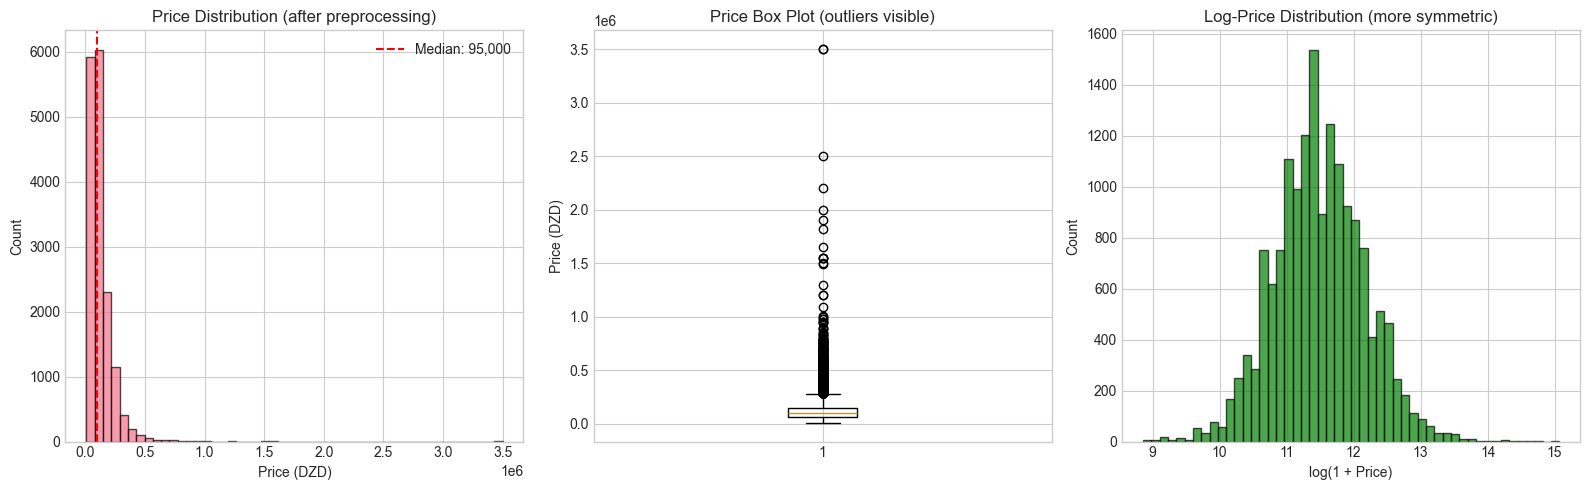

Skewness (PRICES): 7.58
Skewness (RAM_SIZE_GB): 9.18
Skewness (SSD_SIZE_GB): 6.68


In [5]:
# Price distribution and skewness (after preprocessing)
prices = df_clean['PRICES'].dropna()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(prices, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(prices.median(), color='red', linestyle='--', label=f'Median: {prices.median():,.0f}')
axes[0].set_xlabel('Price (DZD)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price Distribution (after preprocessing)')
axes[0].legend()

axes[1].boxplot(prices, vert=True)
axes[1].set_ylabel('Price (DZD)')
axes[1].set_title('Price Box Plot (outliers visible)')

axes[2].hist(np.log1p(prices), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].set_xlabel('log(1 + Price)')
axes[2].set_ylabel('Count')
axes[2].set_title('Log-Price Distribution (more symmetric)')
plt.tight_layout()
plt.show()

print(f"Skewness (PRICES): {skew(prices):.2f}")
if 'RAM_SIZE_GB' in df_clean.columns:
    ram = df_clean['RAM_SIZE_GB'].dropna()
    if len(ram) > 0:
        print(f"Skewness (RAM_SIZE_GB): {skew(ram):.2f}")
if 'SSD_SIZE_GB' in df_clean.columns:
    ssd = df_clean['SSD_SIZE_GB'].dropna()
    if len(ssd) > 0:
        print(f"Skewness (SSD_SIZE_GB): {skew(ssd):.2f}")

---
## 3. Temporal Patterns Analysis

Listing volume and median price by **month** and **year**. Red bars highlight the back-to-school season (Aug–Oct). Median price by month helps spot seasonal price shifts.

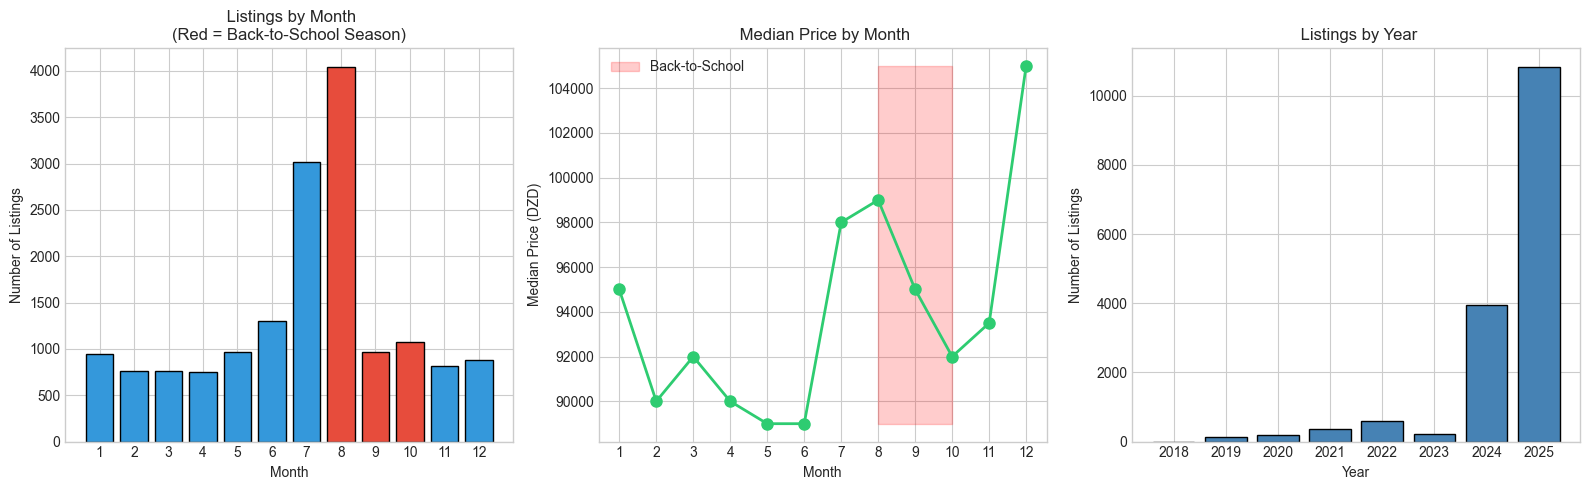

In [6]:
# Visualize temporal patterns
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Listings by month
month_counts = df_clean['listing_month'].value_counts().sort_index()
colors = ['#e74c3c' if m in [8, 9, 10] else '#3498db' for m in month_counts.index]
axes[0].bar(month_counts.index, month_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title(' Listings by Month\n(Red = Back-to-School Season)')
axes[0].set_xticks(range(1, 13))

# Plot 2: Price by month
month_price_preview = df_clean.groupby('listing_month')['PRICES'].median()
axes[1].plot(month_price_preview.index, month_price_preview.values, marker='o', linewidth=2, markersize=8, color='#2ecc71')
axes[1].fill_between([8, 10], [month_price_preview.min()]*2, [month_price_preview.max()]*2, alpha=0.2, color='red', label='Back-to-School')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Median Price (DZD)')
axes[1].set_title(' Median Price by Month')
axes[1].legend()
axes[1].set_xticks(range(1, 13))

# Plot 3: Listings over time (by year)
year_counts = df_clean['listing_year'].value_counts().sort_index()
axes[2].bar(year_counts.index.astype(int), year_counts.values, color='steelblue', edgecolor='black')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Number of Listings')
axes[2].set_title(' Listings by Year')

plt.tight_layout()
plt.show()

#### Business Insights: Temporal Patterns

**Key Findings:**
1. **Back-to-School Surge**: August shows highest listing volume
2. **Price Spike During Peak Season**: Median prices increase during back-to-school months (Aug-Oct)
3. **Summer Low Prices**: June-July shows lowest median prices - off-season opportunity
4. **2025 Dominance**: Majority of data from recent period, showing market growth

---
## 4. Price Distribution Analysis

We compare **price (DZD)** across categories. Box plots use a **log scale** for price so that tiers with very different price ranges remain comparable. Median and variance by tier inform both EDA and regression.

### 4.1 Price by CPU Performance Class

**Takeaway:** High CPU class has a clearly higher median price than Low/Mid-Low: **High CPU = +497% vs Low** (239k vs 40k DZD). This is because High-class CPUs (i7/i9, Ryzen 7/9, Apple M-series) deliver substantially better performance for demanding tasks (video editing, development, gaming), justifying premium pricing. **Buyers:** prioritize CPU class if workload is compute-intensive; **Sellers:** highlight CPU tier prominently in listings.

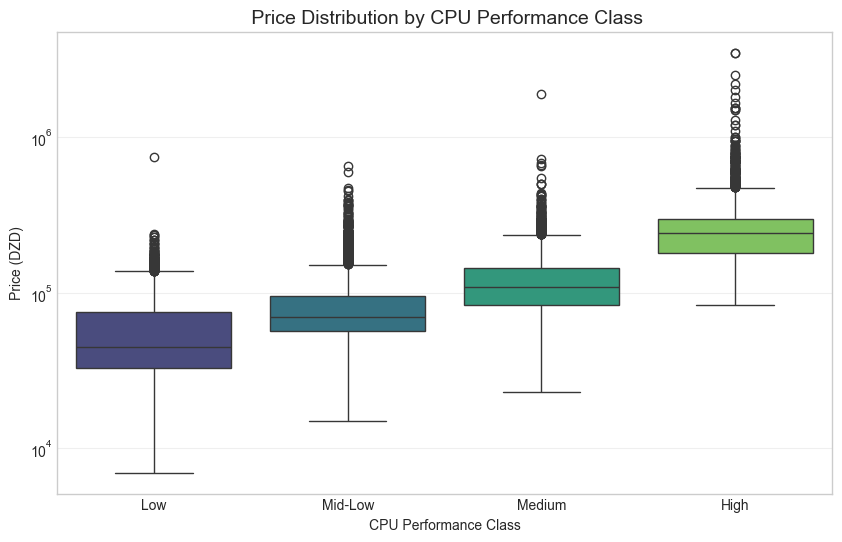


 Price Statistics by CPU Tier:
                         median      mean  count
cpu_performance_class                           
Low                    45000.00  59006.64   2613
Mid-Low                70000.00  84245.52   4773
Medium                109000.00 119092.87   6302
High                  242000.00 275085.26   2595


In [7]:
# Visualize price distribution by CPU class
plt.figure(figsize=(10, 6))
order = ['Low', 'Mid-Low', 'Medium', 'High']
sns.boxplot(data=df_clean, x='cpu_performance_class', y='PRICES', order=order, palette='viridis')
plt.title(' Price Distribution by CPU Performance Class', fontsize=14)
plt.xlabel('CPU Performance Class')
plt.ylabel('Price (DZD)')
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Calculate median prices per tier
tier_stats = df_clean.groupby('cpu_performance_class')['PRICES'].agg(['median', 'mean', 'count'])
print("\n Price Statistics by CPU Tier:")
print(tier_stats.reindex(order))

 Price Volatility by CPU Tier:

Standard Deviation (DZD):
 High      :         187,737 DZD
 Medium    :          59,850 DZD
 Mid-Low   :          46,513 DZD
 Low       :          40,870 DZD


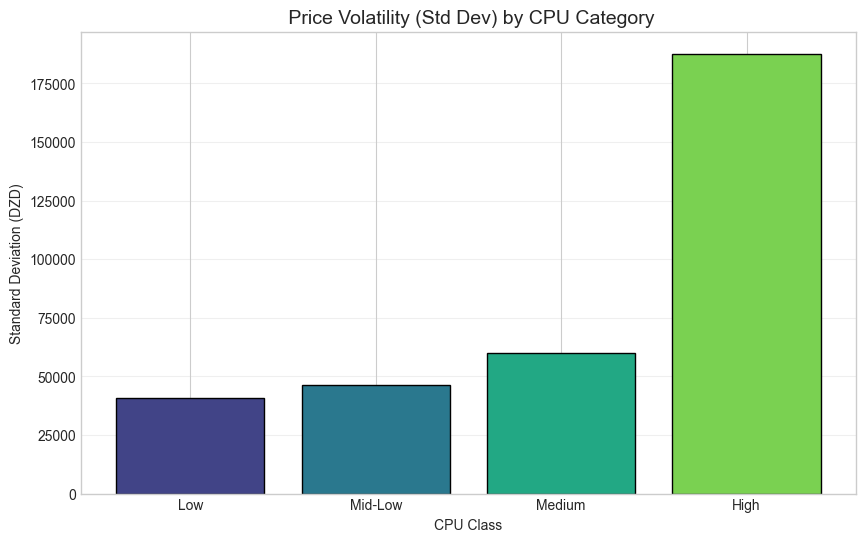

In [8]:
# Calculate price variance by CPU tier
variance_per_category = df_clean.groupby('cpu_performance_class')['PRICES'].var().sort_values(ascending=False)
std_dev_per_category = df_clean.groupby('cpu_performance_class')['PRICES'].std().sort_values(ascending=False)

print(" Price Volatility by CPU Tier:")
print(f"\nStandard Deviation (DZD):")
for tier in ['High', 'Medium', 'Mid-Low', 'Low']:
    if tier in std_dev_per_category.index:
        print(f" {tier:10}: {std_dev_per_category[tier]:>15,.0f} DZD")

# Visualization
plt.figure(figsize=(10, 6))
order = ['Low', 'Mid-Low', 'Medium', 'High']
std_ordered = std_dev_per_category.reindex(order)
plt.bar(std_ordered.index, std_ordered.values, color=sns.color_palette('viridis', 4), edgecolor='black')
plt.title(' Price Volatility (Std Dev) by CPU Category', fontsize=14)
plt.ylabel('Standard Deviation (DZD)')
plt.xlabel('CPU Class')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Takeaway:** Dedicated GPU (especially High tier) raises median price substantially: **High GPU = +271% vs None** (315k vs 85k DZD). The premium exists because discrete GPUs enable gaming, 3D rendering, and ML training that integrated graphics cannot handle—buyers seeking these use cases pay significantly more. **Sellers:** a dedicated GPU is one of the strongest levers to justify higher asking price.

### 4.2 Price by GPU Performance Class

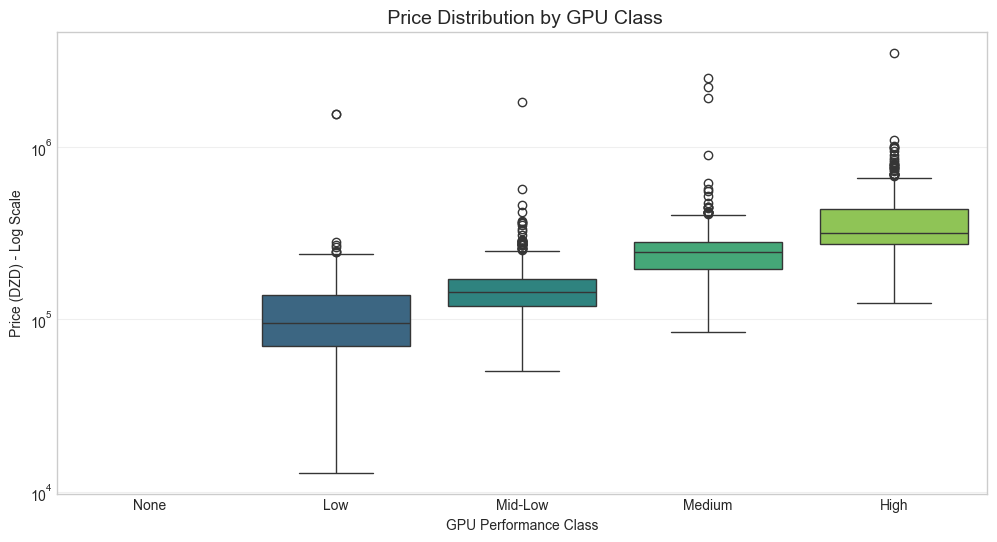

 GPU Performance Distribution:
gpu_performance_class
Mid-Low    1064
Medium      946
High        433
Low         279
Name: count, dtype: int64


In [9]:
# Visualize price distribution by GPU class
plt.figure(figsize=(12, 6))
order = ['None', 'Low', 'Mid-Low', 'Medium', 'High']
sns.boxplot(data=df_clean, x='gpu_performance_class', y='PRICES', order=order, palette='viridis')
plt.title(' Price Distribution by GPU Class', fontsize=14)
plt.xlabel('GPU Performance Class')
plt.ylabel('Price (DZD) - Log Scale')
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f" GPU Performance Distribution:")
print(df_clean['gpu_performance_class'].value_counts())

**Takeaway:** New condition (JAMAIS UTILISÉ) commands a large premium over BON ÉTAT: **+112%** (159k vs 75k DZD median). Buyers pay more than double for untouched laptops because of warranty, zero wear, and perceived risk reduction. **Sellers:** condition is a major lever—listing as "JAMAIS UTILISÉ" when applicable significantly increases expected price; **Buyers:** consider BON ÉTAT for ~50% savings if specs are similar.

### 4.3 Price by Condition

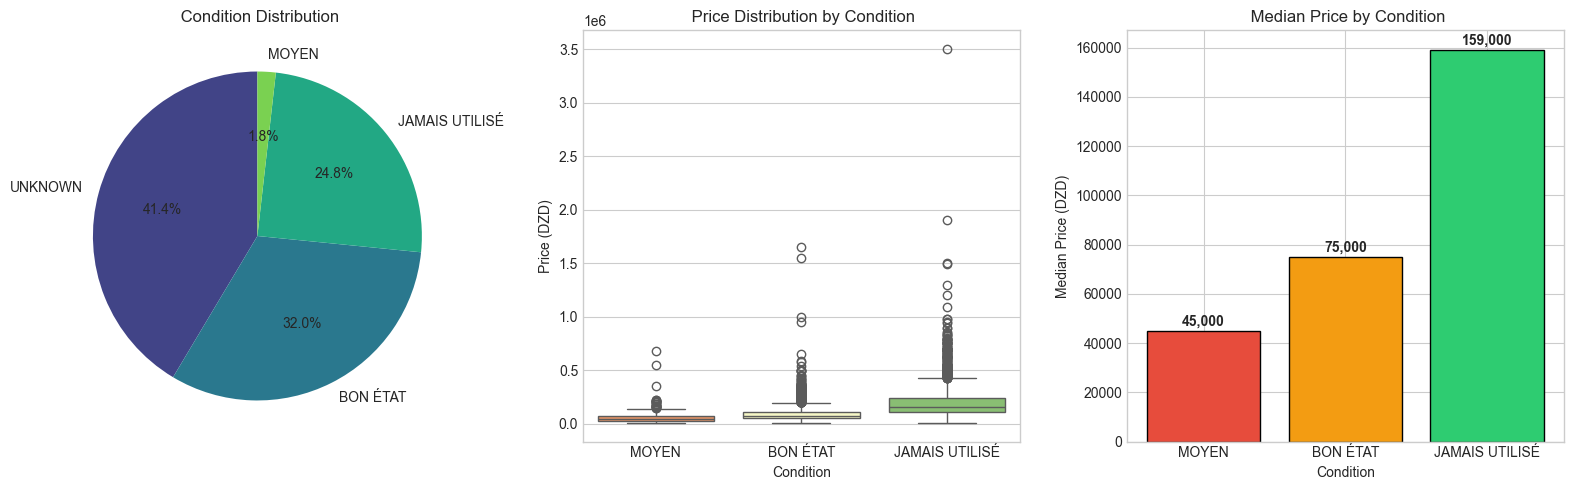


 Actual market depreciation (New vs Good): 52.8%


In [10]:
# Visualization of condition impact
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# A. Condition distribution
cond_counts = df_clean['condition'].value_counts()
axes[0].pie(cond_counts.values, labels=cond_counts.index, autopct='%1.1f%%', startangle=90,
colors=sns.color_palette('viridis', len(cond_counts)))
axes[0].set_title(' Condition Distribution')

# B. Price by condition (box plot)
cond_order = ['MOYEN', 'BON ÉTAT', 'JAMAIS UTILISÉ']
cond_df = df_clean[df_clean['condition'].isin(cond_order)]
sns.boxplot(data=cond_df, x='condition', y='PRICES', order=cond_order, ax=axes[1], palette='RdYlGn')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Price (DZD)')
axes[1].set_title(' Price Distribution by Condition')

# C. Median price by condition
cond_prices = df_clean[df_clean['condition'].isin(cond_order)].groupby('condition')['PRICES'].median()
cond_prices = cond_prices.reindex(cond_order)
colors = ['#e74c3c', '#f39c12', '#2ecc71']
axes[2].bar(cond_prices.index, cond_prices.values, color=colors, edgecolor='black')
axes[2].set_xlabel('Condition')
axes[2].set_ylabel('Median Price (DZD)')
axes[2].set_title(' Median Price by Condition')

# Add value labels
for i, v in enumerate(cond_prices.values):
    if pd.notna(v):
        axes[2].text(i, v + 2000, f'{v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Calculate actual market depreciation
if 'JAMAIS UTILISÉ' in cond_prices.index and 'BON ÉTAT' in cond_prices.index:
    if cond_prices['JAMAIS UTILISÉ'] > 0:
        actual_dep = (cond_prices['JAMAIS UTILISÉ'] - cond_prices['BON ÉTAT']) / cond_prices['JAMAIS UTILISÉ'] * 100
        print(f"\n Actual market depreciation (New vs Good): {actual_dep:.1f}%")

**Takeaway:** DDR5 listings have higher median price than DDR4: **+99%** (175k vs 88k DZD). DDR5 typically accompanies newer 12th–14th gen Intel or Ryzen 7000 series CPUs and faster laptops overall, explaining the premium. When RAM_TYPE is missing, `inferred_ddr` from CPU helps estimate this effect. **Buyers:** DDR5 signals a more recent platform; **Sellers:** highlight DDR5 if present.

### 4.4 Price by RAM Type

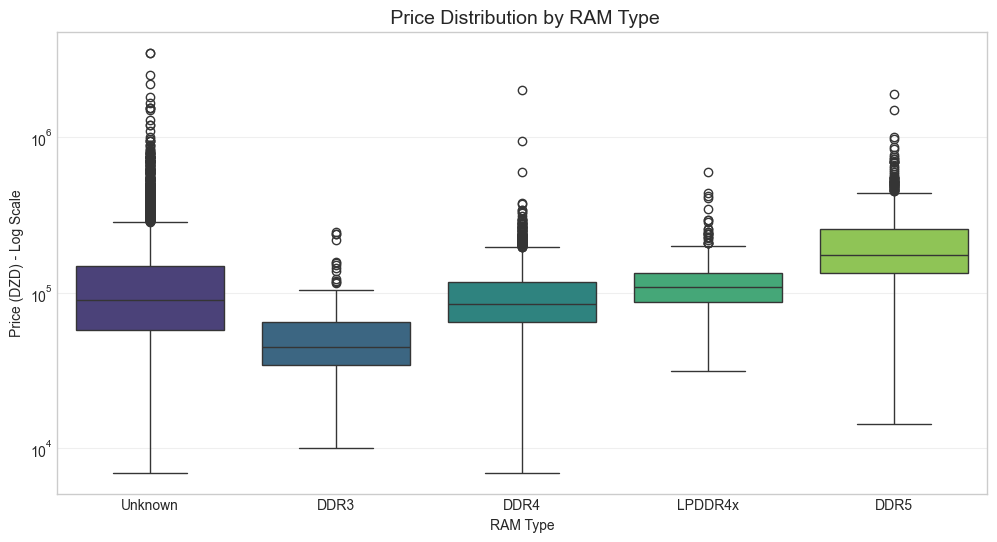

 RAM Type Distribution:
ram_type_class
Unknown    10989
DDR4        3044
DDR5        1522
LPDDR4x      512
DDR3         216
Name: count, dtype: int64


In [11]:
# Visualize RAM type vs price
plt.figure(figsize=(12, 6))
order = ['Unknown', 'DDR3', 'DDR4', 'LPDDR4x', 'DDR5']
sns.boxplot(data=df_clean, x='ram_type_class', y='PRICES', order=order, palette='viridis')
plt.title(' Price Distribution by RAM Type', fontsize=14)
plt.xlabel('RAM Type')
plt.ylabel('Price (DZD) - Log Scale')
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f" RAM Type Distribution:")
print(df_clean['ram_type_class'].value_counts())

**Takeaway:** Higher resolution (QHD/4K) is associated with higher price; resolution class helps segment premium vs standard displays.

### 4.5 Resolution Distribution

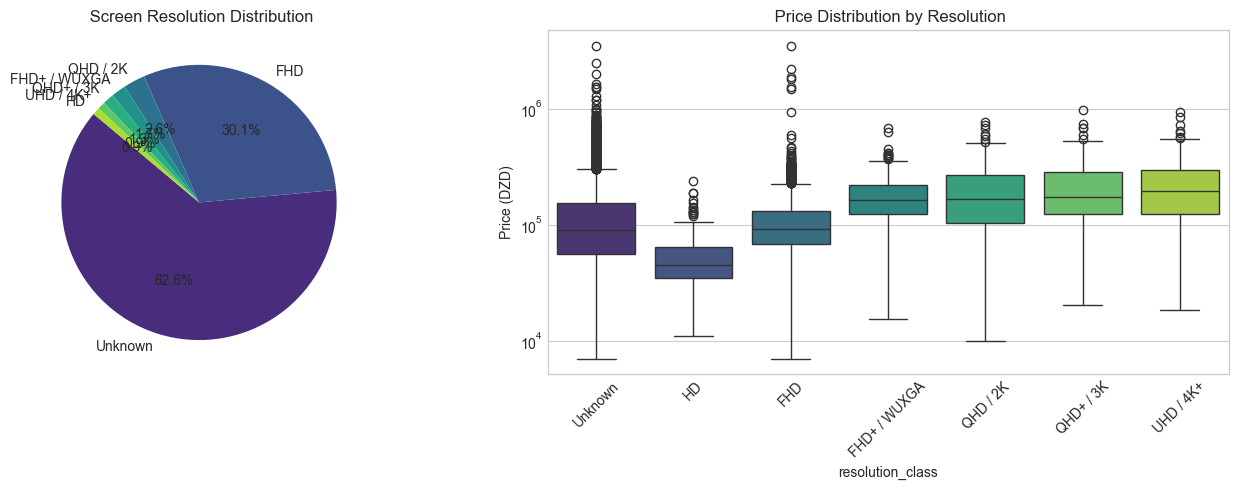

In [12]:
# Visualize resolution distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
res_counts = df_clean['resolution_class'].value_counts()
axes[0].pie(res_counts.values, labels=res_counts.index, autopct='%1.1f%%',
startangle=140, colors=sns.color_palette('viridis', len(res_counts)))
axes[0].set_title(' Screen Resolution Distribution')

# Price boxplot
res_order = ['Unknown', 'HD', 'FHD', 'FHD+ / WUXGA', 'QHD / 2K', 'QHD+ / 3K', 'UHD / 4K+']
sns.boxplot(data=df_clean, x='resolution_class', y='PRICES', order=res_order,
ax=axes[1], palette='viridis')
axes[1].set_title(' Price Distribution by Resolution')
axes[1].set_ylabel('Price (DZD)')
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4.6 Screen Frequency

Screen refresh rate (Hz) and high-refresh flag (> 60 Hz) were engineered in preprocessing; many listings have missing values. We visualize distribution and price by refresh rate where available.

---
## 5. 📈 Feature Correlation Analysis

**Methodology:** We measure association with **price** in two ways:
- **Numerical features**: **Spearman correlation** with `PRICES` (rank-based; robust to skew and outliers).
- **Categorical features**: **Cramér's V** against a binned **Price_Bin** (quintiles of `PRICES`). We bin price so that ordinal association (e.g. "condition vs price tier") is meaningful; using raw continuous price for categorical association would be scale-dependent.

Scores between 0 and 1 indicate strength of association; they do **not** imply causation.

In [13]:
# ============================================================================
# COMPREHENSIVE CORRELATION ANALYSIS
# ============================================================================

print("=" * 80)
print("ANALYZING FEATURE CORRELATIONS WITH PRICE")
print("=" * 80)

def calculate_cramers_v(x, y):
    """Calculate Cramér's V association between two categorical variables."""
    try:
        confusion_matrix = pd.crosstab(x, y)
        if confusion_matrix.size == 0: 
            return 0
        chi2 = ss.chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        return np.sqrt(chi2 / (n * (min(confusion_matrix.shape) - 1)))
    except:
        return 0

# Create price bins for categorical association
df_stats = df_clean.copy()
df_stats['Price_Bin'] = pd.qcut(df_stats['PRICES'], q=5, labels=False, duplicates='drop')

results = []
skip_cols = ['PRICES', 'price_preview', 'Price_Bin']

for col in df_stats.columns:
    if col in skip_cols:
        continue

    temp_df = df_stats[[col, 'PRICES', 'Price_Bin']].dropna()
    if temp_df.empty:
        continue

    # Numerical features: Spearman correlation
    if pd.api.types.is_numeric_dtype(temp_df[col]) or pd.api.types.is_datetime64_any_dtype(temp_df[col]):
        if pd.api.types.is_datetime64_any_dtype(temp_df[col]):
            metric_data = temp_df[col].astype('int64')
        else:
            metric_data = temp_df[col]

        if metric_data.nunique() > 1:
            corr, _ = ss.spearmanr(metric_data, temp_df['PRICES'])
            results.append({
                'Feature': col, 'Score': abs(corr),
                'Type': 'Numerical', 'Method': 'Spearman Correlation'
            })
    else:
        # Categorical: Skip if too many unique values
        if temp_df[col].nunique() > 100:
            continue
        score = calculate_cramers_v(temp_df[col], temp_df['Price_Bin'])
        results.append({
            'Feature': col, 'Score': score,
            'Type': 'Categorical', 'Method': "Cramer's V"
        })

df_res = pd.DataFrame(results).sort_values('Score', ascending=False)
print(f"Analyzed {len(df_res)} features")

ANALYZING FEATURE CORRELATIONS WITH PRICE
Analyzed 54 features


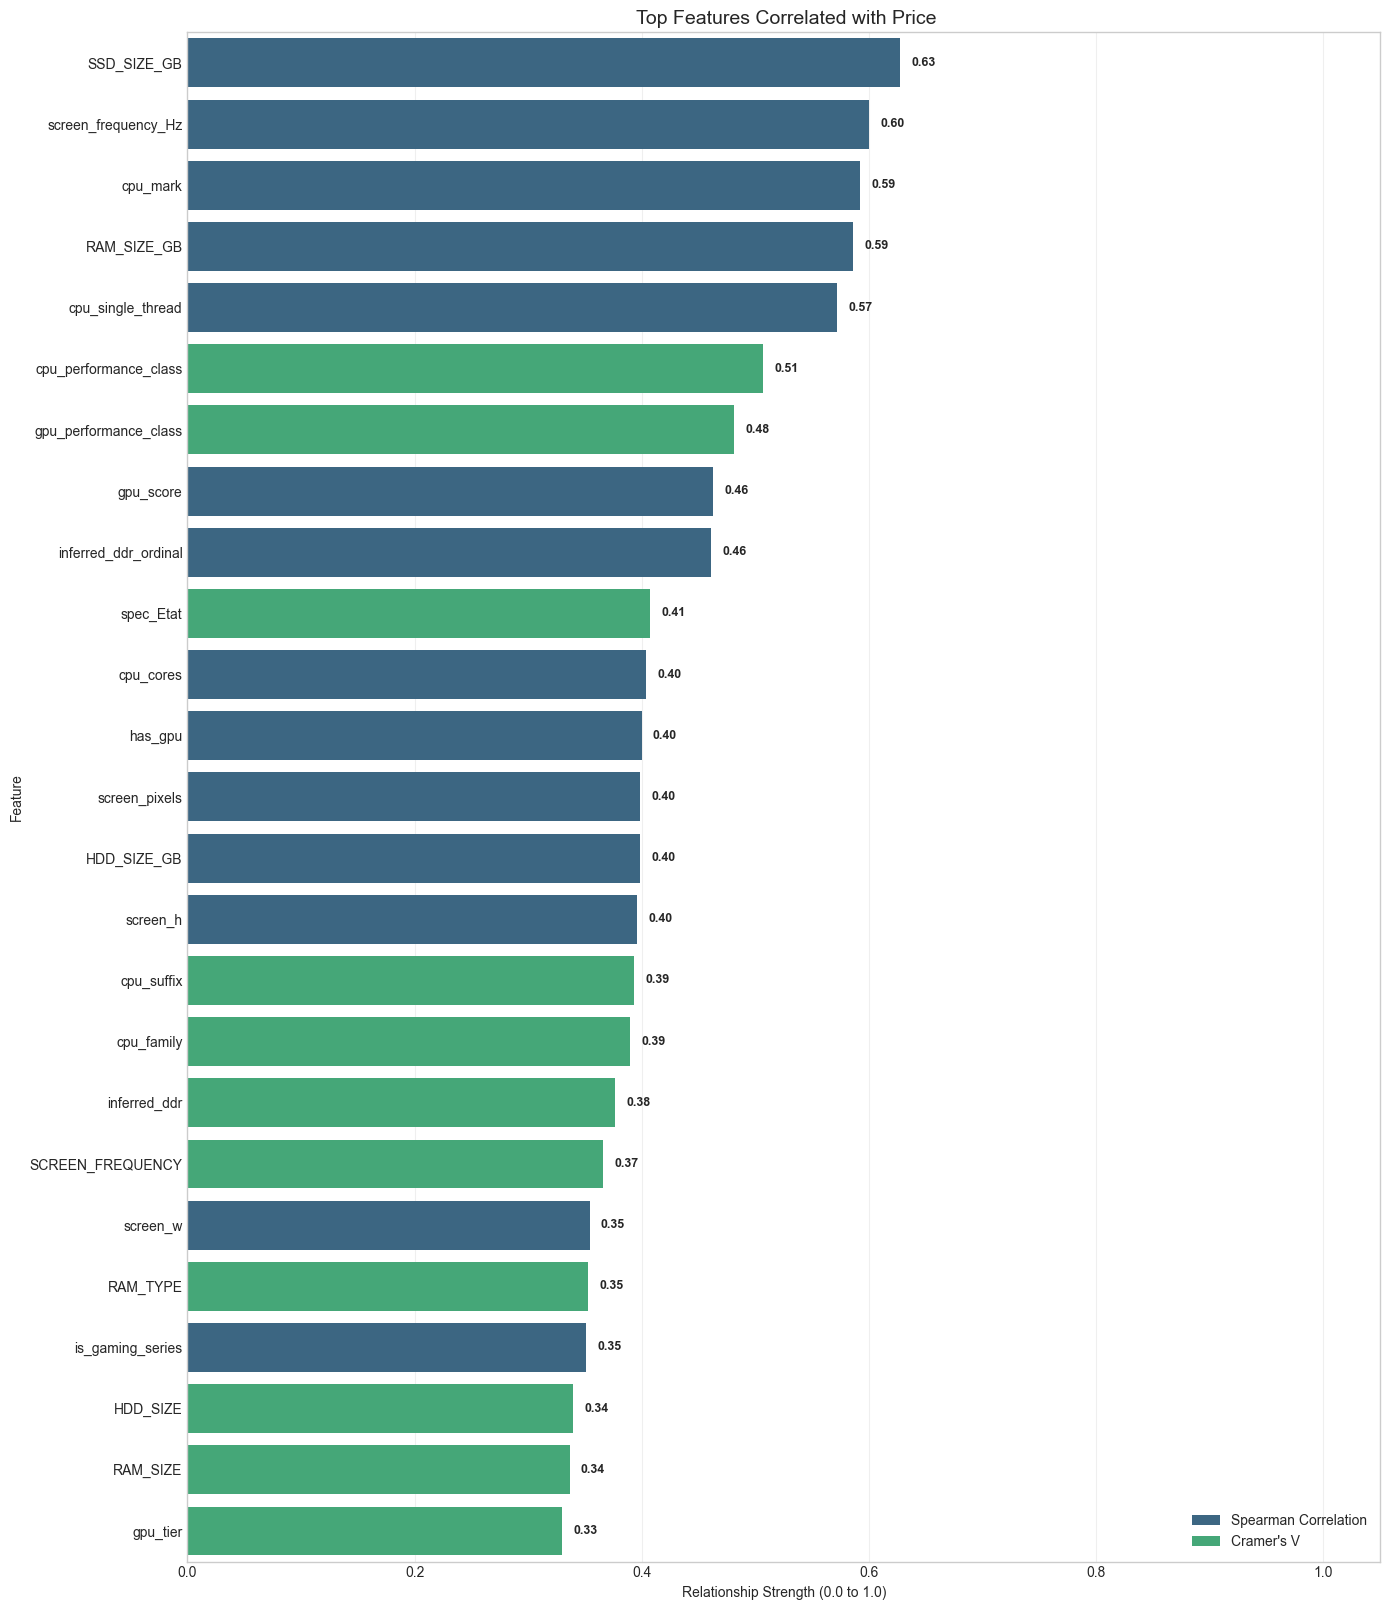


 Top 10 Most Influential Features:
              Feature  Score               Method
          SSD_SIZE_GB   0.63 Spearman Correlation
  screen_frequency_Hz   0.60 Spearman Correlation
             cpu_mark   0.59 Spearman Correlation
          RAM_SIZE_GB   0.59 Spearman Correlation
    cpu_single_thread   0.57 Spearman Correlation
cpu_performance_class   0.51           Cramer's V
gpu_performance_class   0.48           Cramer's V
            gpu_score   0.46 Spearman Correlation
 inferred_ddr_ordinal   0.46 Spearman Correlation
            spec_Etat   0.41           Cramer's V


In [14]:
# Visualize feature correlations
plt.figure(figsize=(14, max(8, len(df_res) * 0.3)))
sns.barplot(data=df_res.head(25), x='Score', y='Feature', hue='Method', dodge=False, palette='viridis')
plt.title(' Top Features Correlated with Price', fontsize=14)
plt.xlabel('Relationship Strength (0.0 to 1.0)')
plt.xlim(0, 1.05)
plt.grid(axis='x', alpha=0.3)
plt.legend(loc='lower right')

# Add score labels
for i, v in enumerate(df_res.head(25)['Score']):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Top 10 Most Influential Features:")
print(df_res[['Feature', 'Score', 'Method']].head(10).to_string(index=False))

### Correlation Heatmap & PassMark vs Price

**Correlation heatmap:** Shows pairwise correlations among numeric features including PassMark scores (`cpu_mark`, `cpu_single_thread`, `gpu_score`) and price. We use **Spearman correlation** (rank-based) because price and benchmark scores are often right-skewed. The heatmap highlights which features move together and how strongly each relates to `PRICES`.

**PassMark vs price scatter plots:** Directly visualize how higher CPU/GPU benchmark scores associate with higher listing prices. Points are subsampled for readability when the dataset is large. These plots answer: *"Do higher PassMark scores consistently command higher prices?"*

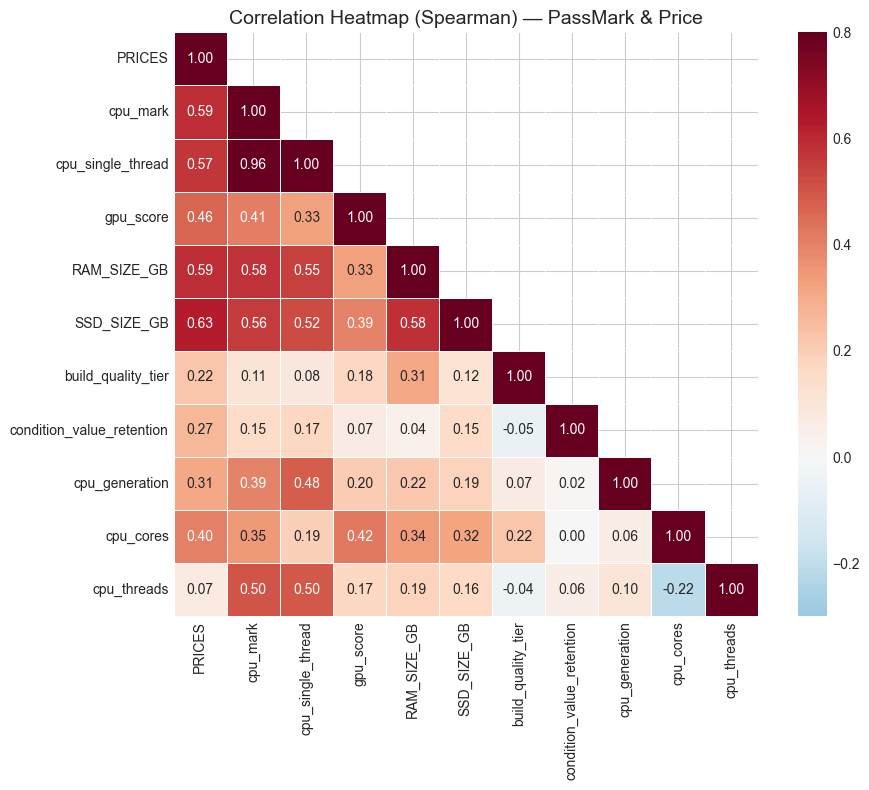


**Takeaway:** The heatmap shows how PassMark scores (cpu_mark, cpu_single_thread, gpu_score) correlate with price and with each other. Strong positive correlation with PRICES indicates these benchmarks are good price drivers.


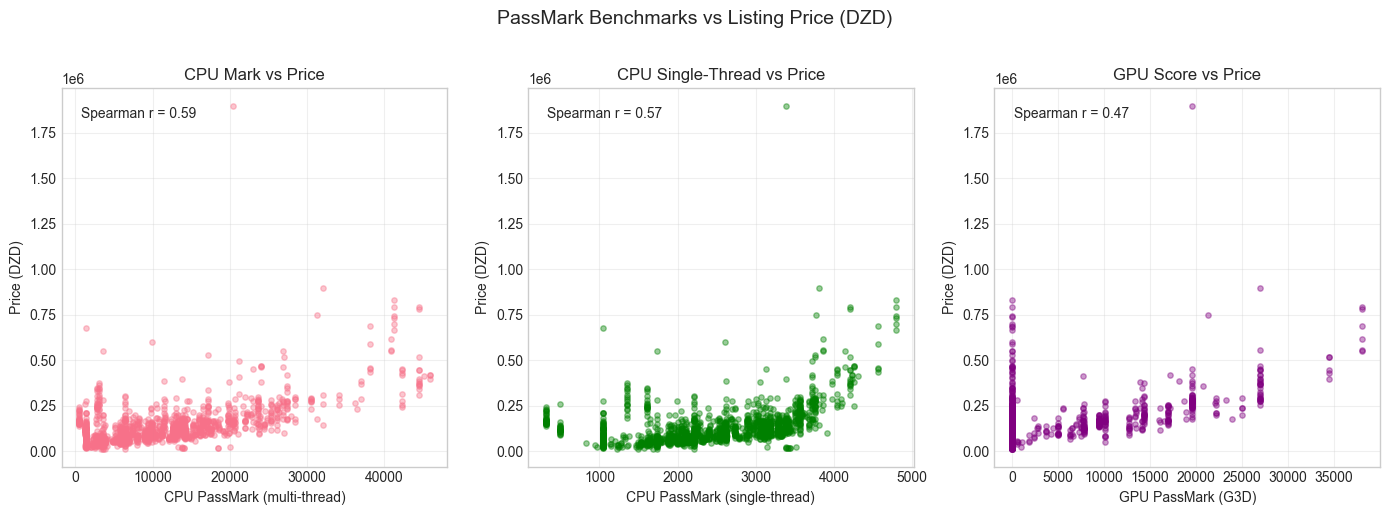


**Takeaway:** Higher CPU and GPU PassMark scores are associated with higher prices; the Spearman r values quantify this relationship. Scatter spread reflects other factors (brand, condition, RAM, etc.).


In [15]:
# ============================================================================
# CORRELATION HEATMAP (including PassMark features) & PASSMARK VS PRICE
# ============================================================================

# Numeric columns to include (PassMark + price + other key numeric)
numeric_for_heatmap = [
    'PRICES', 'cpu_mark', 'cpu_single_thread', 'gpu_score',
    'RAM_SIZE_GB', 'SSD_SIZE_GB', 'build_quality_tier', 'condition_value_retention',
    'cpu_generation', 'cpu_cores', 'cpu_threads'
]
# Keep only columns that exist
numeric_for_heatmap = [c for c in numeric_for_heatmap if c in df_clean.columns]

df_numeric = df_clean[numeric_for_heatmap].dropna(how='all', subset=[c for c in numeric_for_heatmap if c != 'PRICES'])
# Spearman correlation (robust to skew)
corr_matrix = df_numeric.corr(method='spearman')

# --- Correlation heatmap ---
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1) # Upper triangle only for less clutter
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-0.3, vmax=0.8)
ax.set_title('Correlation Heatmap (Spearman) — PassMark & Price', fontsize=14)
plt.tight_layout()
plt.show()

# Takeaway
print("\n**Takeaway:** The heatmap shows how PassMark scores (cpu_mark, cpu_single_thread, gpu_score) correlate with price and with each other. Strong positive correlation with PRICES indicates these benchmarks are good price drivers.")

# ============================================================================
# PASSMARK VS PRICE — Scatter plots
# ============================================================================

# Subsample for readable scatter (max 2000 points)
n_scatter = min(2000, len(df_clean))
df_scatter = df_clean.dropna(subset=['PRICES']).sample(n=n_scatter, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# cpu_mark vs PRICES
ax0 = axes[0]
valid = df_scatter['cpu_mark'].notna()
ax0.scatter(df_scatter.loc[valid, 'cpu_mark'], df_scatter.loc[valid, 'PRICES'], alpha=0.4, s=15)
ax0.set_xlabel('CPU PassMark (multi-thread)')
ax0.set_ylabel('Price (DZD)')
ax0.set_title('CPU Mark vs Price')
ax0.grid(True, alpha=0.3)
if valid.sum() > 0:
    r = df_scatter.loc[valid, ['cpu_mark', 'PRICES']].corr(method='spearman').iloc[0, 1]
    ax0.text(0.05, 0.95, f"Spearman r = {r:.2f}", transform=ax0.transAxes, fontsize=10, verticalalignment='top')

# cpu_single_thread vs PRICES
ax1 = axes[1]
valid = df_scatter['cpu_single_thread'].notna()
ax1.scatter(df_scatter.loc[valid, 'cpu_single_thread'], df_scatter.loc[valid, 'PRICES'], alpha=0.4, s=15, color='green', label='_nolegend_')
ax1.set_xlabel('CPU PassMark (single-thread)')
ax1.set_ylabel('Price (DZD)')
ax1.set_title('CPU Single-Thread vs Price')
ax1.grid(True, alpha=0.3)
if valid.sum() > 0:
    r = df_scatter.loc[valid, ['cpu_single_thread', 'PRICES']].corr(method='spearman').iloc[0, 1]
    ax1.text(0.05, 0.95, f"Spearman r = {r:.2f}", transform=ax1.transAxes, fontsize=10, verticalalignment='top')

# gpu_score vs PRICES (exclude 0 for dedicated-GPU view, or include for full picture)
ax2 = axes[2]
valid = df_scatter['gpu_score'].notna() & (df_scatter['gpu_score'] >= 0)
ax2.scatter(df_scatter.loc[valid, 'gpu_score'], df_scatter.loc[valid, 'PRICES'], alpha=0.4, s=15, color='purple', label='_nolegend_')
ax2.set_xlabel('GPU PassMark (G3D)')
ax2.set_ylabel('Price (DZD)')
ax2.set_title('GPU Score vs Price')
ax2.grid(True, alpha=0.3)
if valid.sum() > 0:
    r = df_scatter.loc[valid, ['gpu_score', 'PRICES']].corr(method='spearman').iloc[0, 1]
    ax2.text(0.05, 0.95, f"Spearman r = {r:.2f}", transform=ax2.transAxes, fontsize=10, verticalalignment='top')

plt.suptitle('PassMark Benchmarks vs Listing Price (DZD)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n**Takeaway:** Higher CPU and GPU PassMark scores are associated with higher prices; the Spearman r values quantify this relationship. Scatter spread reflects other factors (brand, condition, RAM, etc.).")

**Takeaway:** Brand market share and median price by brand show Apple sits in the premium band: **Apple = +78% vs Lenovo**, +62% vs HP (149k vs 83.5k vs 92k DZD median). Apple's premium stems from build quality, ecosystem lock-in, and resale value. **Sellers:** Apple listings can be priced higher; **Buyers:** expect to pay ~60–80% more for Apple vs mainstream brands at similar spec tier.

---
## 6. Brand Analysis

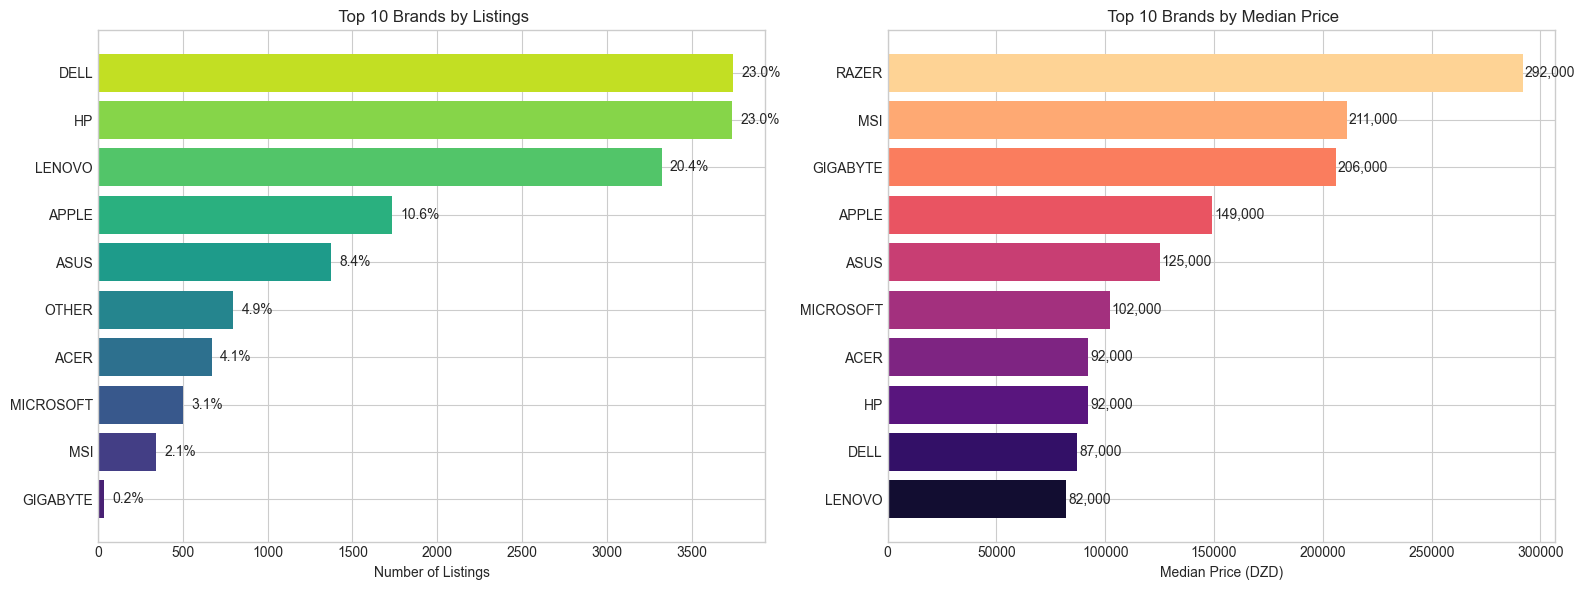

In [16]:
# Brand distribution and pricing
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Market share by brand
brand_counts = df_clean['brand'].value_counts().head(10)
axes[0].barh(brand_counts.index[::-1], brand_counts.values[::-1], color=sns.color_palette('viridis', 10))
axes[0].set_xlabel('Number of Listings')
axes[0].set_title(' Top 10 Brands by Listings')

# Add percentage labels
total = brand_counts.sum()
for i, v in enumerate(brand_counts.values[::-1]):
    pct = v / len(df_clean) * 100
    axes[0].text(v + 50, i, f'{pct:.1f}%', va='center')

# Median price by brand
brand_prices = df_clean.groupby('brand')['PRICES'].median().sort_values(ascending=False).head(10)
axes[1].barh(brand_prices.index[::-1], brand_prices.values[::-1], color=sns.color_palette('magma', 10))
axes[1].set_xlabel('Median Price (DZD)')
axes[1].set_title(' Top 10 Brands by Median Price')

# Add price labels
for i, v in enumerate(brand_prices.values[::-1]):
    axes[1].text(v + 1000, i, f'{v:,.0f}', va='center')

plt.tight_layout()
plt.show()

---
## Price Premium Summary

Below we compute the **median price premium** for key features, quantifying how much each factor adds to the listing price. These numbers support the takeaways above and help buyers/sellers understand what drives price.

In [17]:
# ============================================================================
# PRICE PREMIUM SUMMARY (QUANTIFIED)
# ============================================================================

def pct_diff(a, b):
    """Percentage difference: (a - b) / b * 100"""
    return ((a - b) / b) * 100 if b > 0 else 0

print("=" * 60)
print("PRICE PREMIUMS BY FEATURE (median comparison)")
print("=" * 60)

# Condition
cond_new = df_clean[df_clean['condition'] == 'JAMAIS UTILISÉ']['PRICES'].median()
cond_bon = df_clean[df_clean['condition'] == 'BON ÉTAT']['PRICES'].median()
print(f"\n1. CONDITION:")
print(f"   JAMAIS UTILISÉ: {cond_new:,.0f} DZD (median)")
print(f"   BON ÉTAT: {cond_bon:,.0f} DZD (median)")
print(f"   → Premium: +{pct_diff(cond_new, cond_bon):.0f}%")

# GPU
gpu_high = df_clean[df_clean['gpu_performance_class'] == 'High']['PRICES'].median()
gpu_none = df_clean[df_clean['gpu_performance_class'].isna()]['PRICES'].median()
print(f"\n2. GPU TIER:")
print(f"   High GPU: {gpu_high:,.0f} DZD (median)")
print(f"   None/Integ:{gpu_none:,.0f} DZD (median)")
print(f"   → Premium: +{pct_diff(gpu_high, gpu_none):.0f}%")

# CPU
cpu_high = df_clean[df_clean['cpu_performance_class'] == 'High']['PRICES'].median()
cpu_low = df_clean[df_clean['cpu_performance_class'] == 'Low']['PRICES'].median()
print(f"\n3. CPU TIER:")
print(f"   High CPU: {cpu_high:,.0f} DZD (median)")
print(f"   Low CPU: {cpu_low:,.0f} DZD (median)")
print(f"   → Premium: +{pct_diff(cpu_high, cpu_low):.0f}%")

# Brand
brand_apple = df_clean[df_clean['brand'] == 'APPLE']['PRICES'].median()
brand_lenovo = df_clean[df_clean['brand'] == 'LENOVO']['PRICES'].median()
brand_hp = df_clean[df_clean['brand'] == 'HP']['PRICES'].median()
print(f"\n4. BRAND:")
print(f"   Apple: {brand_apple:,.0f} DZD (median)")
print(f"   Lenovo: {brand_lenovo:,.0f} DZD (median)")
print(f"   HP: {brand_hp:,.0f} DZD (median)")
print(f"   → Apple vs Lenovo: +{pct_diff(brand_apple, brand_lenovo):.0f}%")
print(f"   → Apple vs HP: +{pct_diff(brand_apple, brand_hp):.0f}%")

# RAM type
if 'RAM_TYPE' in df_clean.columns:
    ram_ddr5 = df_clean[df_clean['RAM_TYPE'].str.contains('DDR5', na=False)]['PRICES'].median()
    ram_ddr4 = df_clean[df_clean['RAM_TYPE'].str.contains('DDR4', na=False)]['PRICES'].median()
    print(f"\n5. RAM TYPE:")
    print(f"   DDR5: {ram_ddr5:,.0f} DZD (median)")
    print(f"   DDR4: {ram_ddr4:,.0f} DZD (median)")
    print(f"   → Premium: +{pct_diff(ram_ddr5, ram_ddr4):.0f}%")

print("\n" + "=" * 60)

PRICE PREMIUMS BY FEATURE (median comparison)

1. CONDITION:
   JAMAIS UTILISÉ: 159,000 DZD (median)
   BON ÉTAT: 75,000 DZD (median)
   → Premium: +112%

2. GPU TIER:
   High GPU: 318,000 DZD (median)
   None/Integ:85,000 DZD (median)
   → Premium: +274%

3. CPU TIER:
   High CPU: 242,000 DZD (median)
   Low CPU: 45,000 DZD (median)
   → Premium: +438%

4. BRAND:
   Apple: 149,000 DZD (median)
   Lenovo: 82,000 DZD (median)
   HP: 92,000 DZD (median)
   → Apple vs Lenovo: +82%
   → Apple vs HP: +62%

5. RAM TYPE:
   DDR5: 175,000 DZD (median)
   DDR4: 88,000 DZD (median)
   → Premium: +99%



### Brand & Gaming Premiums (Raw and Similar Specs)

We compute **brand premiums** (e.g., Apple vs Dell) and **gaming series premium** (gaming vs consumer series) in two ways:

1. **Raw premium**: Median price of brand A vs brand B (or gaming vs non-gaming) across all listings. Simple but confounded by spec mix (e.g., Apple sells more high-end configs).
2. **Similar specs premium**: Within segments with comparable **CPU class**, **GPU class**, and **condition**, we compare median prices. This isolates the brand/series effect from spec differences.

**Minimum segment size (fair comparison):** For similar-specs we only use segments where **each brand (or each series) has at least N listings** in that segment. Otherwise comparing 10 Apple vs 500 HP in "same hardware" would be unfair. You can set `MIN_LISTINGS_PER_BRAND_IN_SEGMENT` (e.g. 5 or 10) in the code below.

In [18]:
# ============================================================================
# BRAND PREMIUMS: APPLE vs DELL (RAW + SIMILAR SPECS)
# ============================================================================

def pct_premium(high_median, low_median):
    """Percentage premium: (high - low) / low * 100"""
    return ((high_median - low_median) / low_median) * 100 if low_median > 0 else 0

# Minimum listings per brand/series in a segment for fair comparison (avoid 10 Apple vs 500 HP)
MIN_LISTINGS_PER_BRAND_IN_SEGMENT = 5 # increase to 10 for stricter fairness

raw_apple_dell = raw_apple_lenovo = raw_apple_hp = None
premiums_similar = []
avg_similar = None
raw_gaming_premium = None
premiums_gaming = []
avg_gaming_similar = None

print("=" * 70)
print("BRAND & GAMING PREMIUMS")
print("=" * 70)

# ---------------------------------------------------------------------------
# 1. RAW BRAND PREMIUMS
# ---------------------------------------------------------------------------
print("\n   1. RAW BRAND PREMIUMS (all listings):")
print("-" * 50)

brands_compare = ['APPLE', 'DELL', 'LENOVO', 'HP', 'ASUS', 'ACER']
brand_medians = {}
for b in brands_compare:
    if b in df_clean['brand'].values:
        brand_medians[b] = df_clean[df_clean['brand'] == b]['PRICES'].median()

if 'APPLE' in brand_medians and 'DELL' in brand_medians:
    raw_apple_dell = pct_premium(brand_medians['APPLE'], brand_medians['DELL'])
    print(f"   Apple vs Dell: +{raw_apple_dell:.1f}% (Apple median: {brand_medians['APPLE']:,.0f} DZD, Dell: {brand_medians['DELL']:,.0f} DZD)")
if 'APPLE' in brand_medians and 'LENOVO' in brand_medians:
    raw_apple_lenovo = pct_premium(brand_medians['APPLE'], brand_medians['LENOVO'])
    print(f"   Apple vs Lenovo: +{raw_apple_lenovo:.1f}% (Apple: {brand_medians['APPLE']:,.0f}, Lenovo: {brand_medians['LENOVO']:,.0f} DZD)")
if 'APPLE' in brand_medians and 'HP' in brand_medians:
    raw_apple_hp = pct_premium(brand_medians['APPLE'], brand_medians['HP'])
    print(f"   Apple vs HP: +{raw_apple_hp:.1f}% (Apple: {brand_medians['APPLE']:,.0f}, HP: {brand_medians['HP']:,.0f} DZD)")

# ---------------------------------------------------------------------------
# 2. SIMILAR SPECS: APPLE vs DELL (same CPU class, GPU class, condition)
# ---------------------------------------------------------------------------
print("\n   2. APPLE vs DELL FOR SIMILAR SPECS:")
print("-" * 50)

df_apple = df_clean[df_clean['brand'] == 'APPLE'].copy()
df_dell = df_clean[df_clean['brand'] == 'DELL'].copy()

if len(df_apple) > 0 and len(df_dell) > 0:
    df_clean['_segment'] = (
        df_clean['cpu_performance_class'].fillna('Unknown').astype(str) + '_' +
        df_clean['gpu_performance_class'].fillna('None').astype(str) + '_' +
        df_clean['condition'].fillna('UNKNOWN').astype(str)
    )
    segments = df_clean['_segment'].value_counts()
    premiums_similar = []
    for seg in segments.index:
        sub = df_clean[df_clean['_segment'] == seg]
        apple_med = sub[sub['brand'] == 'APPLE']['PRICES'].median()
        dell_med = sub[sub['brand'] == 'DELL']['PRICES'].median()
        n_apple = (sub['brand'] == 'APPLE').sum()
        n_dell = (sub['brand'] == 'DELL').sum()
        if n_apple >= MIN_LISTINGS_PER_BRAND_IN_SEGMENT and n_dell >= MIN_LISTINGS_PER_BRAND_IN_SEGMENT and dell_med > 0:
            prem = pct_premium(apple_med, dell_med)
            premiums_similar.append(prem)
    df_clean.drop(columns=['_segment'], inplace=True, errors='ignore')
    if premiums_similar:
        avg_similar = sum(premiums_similar) / len(premiums_similar)
        print(f"   Apple vs Dell (similar specs): +{avg_similar:.1f}% average across {len(premiums_similar)} comparable segments")
        print(f"   (Segments: same CPU class + GPU class + condition, min {MIN_LISTINGS_PER_BRAND_IN_SEGMENT} listings per brand)")
    else:
        avg_similar = raw_apple_dell if raw_apple_dell is not None else 0
        print(f"   Not enough overlapping segments (min {MIN_LISTINGS_PER_BRAND_IN_SEGMENT} per brand); raw premium: +{avg_similar:.1f}%")
else:
    print("   Insufficient Apple or Dell data for similar-specs comparison.")

# ---------------------------------------------------------------------------
# 3. GAMING SERIES vs CONSUMER SERIES
# ---------------------------------------------------------------------------
print("\n   3. GAMING SERIES vs CONSUMER SERIES:")
print("-" * 50)

if 'is_gaming_series' in df_clean.columns:
    gaming_median = df_clean[df_clean['is_gaming_series'] == True]['PRICES'].median()
    consumer_median = df_clean[df_clean['is_gaming_series'] == False]['PRICES'].median()
    n_gaming = (df_clean['is_gaming_series'] == True).sum()
    n_consumer = (df_clean['is_gaming_series'] == False).sum()
    if n_gaming >= 10 and n_consumer >= 10 and consumer_median > 0:
        raw_gaming_premium = pct_premium(gaming_median, consumer_median)
        print(f"   Raw: Gaming series = +{raw_gaming_premium:.1f}% vs consumer series")
        print(f"   (Gaming median: {gaming_median:,.0f} DZD, n={n_gaming:,} | Consumer median: {consumer_median:,.0f} DZD, n={n_consumer:,})")
    if 'cpu_performance_class' in df_clean.columns:
        df_clean['_seg_cpu_cond'] = (
            df_clean['cpu_performance_class'].fillna('Unknown').astype(str) + '_' +
            df_clean['condition'].fillna('UNKNOWN').astype(str)
        )
        premiums_gaming = []
        for seg in df_clean['_seg_cpu_cond'].unique():
            sub = df_clean[df_clean['_seg_cpu_cond'] == seg]
            g_med = sub[sub['is_gaming_series'] == True]['PRICES'].median()
            c_med = sub[sub['is_gaming_series'] == False]['PRICES'].median()
            n_g = (sub['is_gaming_series'] == True).sum()
            n_c = (sub['is_gaming_series'] == False).sum()
            if n_g >= MIN_LISTINGS_PER_BRAND_IN_SEGMENT and n_c >= MIN_LISTINGS_PER_BRAND_IN_SEGMENT and c_med > 0:
                premiums_gaming.append(pct_premium(g_med, c_med))
        df_clean.drop(columns=['_seg_cpu_cond'], inplace=True, errors='ignore')
        if premiums_gaming:
            avg_gaming_similar = sum(premiums_gaming) / len(premiums_gaming)
            print(f"   Similar specs (same CPU class + condition): Gaming = +{avg_gaming_similar:.1f}% vs consumer (avg over {len(premiums_gaming)} segments)")
else:
    print("   is_gaming_series column not found.")

# ---------------------------------------------------------------------------
# 4. SUMMARY
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("   SUMMARY: BRAND & GAMING PREMIUMS")
print("=" * 70)
if raw_apple_dell is not None:
    print(f"   - Apple = +{raw_apple_dell:.0f}% vs Dell (raw)")
if avg_similar is not None:
    print(f"   - Apple = +{avg_similar:.0f}% vs Dell for similar specs")
if raw_gaming_premium is not None:
    print(f"   - Gaming series = +{raw_gaming_premium:.0f}% vs consumer series (raw)")
if avg_gaming_similar is not None:
    print(f"   - Gaming series = +{avg_gaming_similar:.0f}% vs consumer for similar CPU+condition")
print("=" * 70)

BRAND & GAMING PREMIUMS

   1. RAW BRAND PREMIUMS (all listings):
--------------------------------------------------
   Apple vs Dell: +71.3% (Apple median: 149,000 DZD, Dell: 87,000 DZD)
   Apple vs Lenovo: +81.7% (Apple: 149,000, Lenovo: 82,000 DZD)
   Apple vs HP: +62.0% (Apple: 149,000, HP: 92,000 DZD)

   2. APPLE vs DELL FOR SIMILAR SPECS:
--------------------------------------------------


   Apple vs Dell (similar specs): +44.1% average across 14 comparable segments
   (Segments: same CPU class + GPU class + condition, min 5 listings per brand)

   3. GAMING SERIES vs CONSUMER SERIES:
--------------------------------------------------
   Raw: Gaming series = +130.3% vs consumer series
   (Gaming median: 205,000 DZD, n=1,381 | Consumer median: 89,000 DZD, n=14,902)
   Similar specs (same CPU class + condition): Gaming = +62.6% vs consumer (avg over 10 segments)

   SUMMARY: BRAND & GAMING PREMIUMS
   - Apple = +71% vs Dell (raw)
   - Apple = +44% vs Dell for similar specs
   - Gaming series = +130% vs consumer series (raw)
   - Gaming series = +63% vs consumer for similar CPU+condition


---
## 5. Market Segmentation Analysis (K-Means Clustering)

We perform **unsupervised clustering** on configuration features only (no price) to discover natural market segments. This helps:
- **Buyers:** Understand which segment a laptop belongs to (budget, mid-range, premium, gaming)
- **Sellers:** Position listings within the right competitive segment
- **Modeling:** Add cluster_id as a feature to capture segment-specific pricing patterns

**Design choices:**
- **No price in clustering:** Ensures segments are based on specs, not price (avoids target leakage)
- **K chosen via elbow plot:** We use K=4 for interpretability (budget, mid-range, premium, gaming)
- **Features used:** RAM, storage, CPU performance, GPU tier, condition, etc.

MARKET SEGMENTATION (K-Means on Configuration Features)

Clustering features (10): ['RAM_SIZE_GB', 'SSD_SIZE_GB', 'cpu_class_ordinal', 'cpu_generation', 'gpu_class_ordinal', 'condition_value_retention', 'inferred_ddr_ordinal', 'cpu_mark', 'gpu_score', 'screen_pixels']
Samples available for clustering: 5,141


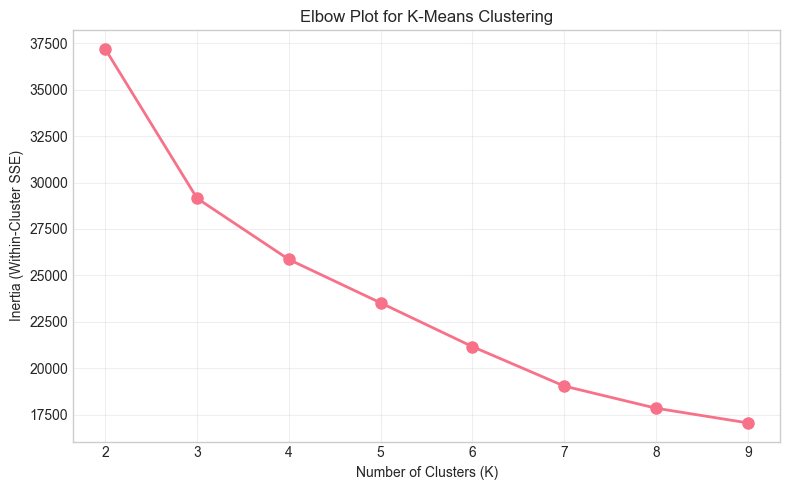


   Elbow plot shows diminishing returns after K=4


In [19]:
# ============================================================================
# MARKET SEGMENTATION: K-MEANS CLUSTERING (CONFIGURATION ONLY)
# ============================================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("MARKET SEGMENTATION (K-Means on Configuration Features)")
print("=" * 70)

# Map performance classes to ordinal values
cpu_class_map = {'Low': 1, 'Mid-Low': 2, 'Medium': 3, 'High': 4}
gpu_class_map = {'Low': 1, 'Mid-Low': 2, 'Medium': 3, 'High': 4}

df_clean['cpu_class_ordinal'] = df_clean['cpu_performance_class'].map(cpu_class_map).fillna(0)
df_clean['gpu_class_ordinal'] = df_clean['gpu_performance_class'].map(gpu_class_map).fillna(0)

# Features for clustering (NO PRICE, NO TIME)
cluster_features = ['RAM_SIZE_GB', 'SSD_SIZE_GB', 'cpu_class_ordinal', 'cpu_generation']

# Add optional features if they exist
optional_features = ['gpu_class_ordinal', 'condition_value_retention', 'inferred_ddr_ordinal', 
                     'cpu_mark', 'gpu_score', 'screen_pixels']
for f in optional_features:
    if f in df_clean.columns:
        cluster_features.append(f)

print(f"\nClustering features ({len(cluster_features)}): {cluster_features}")

# Prepare data (drop rows with missing values in cluster features)
df_cluster = df_clean[cluster_features + ['PRICES']].dropna()
X_cluster = df_cluster[cluster_features]
print(f"Samples available for clustering: {len(X_cluster):,}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# ---------------------------------------------------------------------------
# ELBOW PLOT to choose K
# ---------------------------------------------------------------------------
k_values = range(2, 10)
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster SSE)')
plt.title('Elbow Plot for K-Means Clustering')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

print("\n   Elbow plot shows diminishing returns after K=4")

In [20]:
# ============================================================================
# FIT K-MEANS WITH K=4 AND ANALYZE CLUSTER PROFILES
# ============================================================================

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_cluster['cluster_id'] = kmeans.fit_predict(X_scaled)

print("=" * 70)
print(f"CLUSTER PROFILES (K={optimal_k})")
print("=" * 70)

# Cluster summary with available columns
agg_dict = {
    'PRICES': ['median', 'mean', 'count'],
    'RAM_SIZE_GB': 'median',
    'SSD_SIZE_GB': 'median',
    'cpu_class_ordinal': 'median',
}
if 'cpu_generation' in df_cluster.columns:
    agg_dict['cpu_generation'] = 'median'

cluster_summary = df_cluster.groupby('cluster_id').agg(agg_dict).round(1)

# Flatten column names
cluster_summary.columns = ['Price_Median', 'Price_Mean', 'Count', 'RAM_GB', 'SSD_GB', 'CPU_Class'] + \
                          (['CPU_Gen'] if 'cpu_generation' in df_cluster.columns else [])
cluster_summary['Market_Share'] = (cluster_summary['Count'] / cluster_summary['Count'].sum() * 100).round(1)

# Sort by median price for interpretation
cluster_summary = cluster_summary.sort_values('Price_Median')

print("\n   Cluster Profiles (sorted by median price):")
print(cluster_summary.to_string())

# Assign segment names based on median price and specs
print("\n   Segment Interpretation:")
for idx, (cluster_id, row) in enumerate(cluster_summary.iterrows()):
    if idx == 0:
        segment = "Budget"
    elif idx == 1:
        segment = "Mid-Range"
    elif idx == 2:
        segment = "Premium"
    else:
        segment = "High-End/Gaming"

    print(f"   Cluster {cluster_id} → {segment}: {row['Count']:,.0f} listings ({row['Market_Share']:.1f}%), "
          f"median {row['Price_Median']:,.0f} DZD")

CLUSTER PROFILES (K=4)

   Cluster Profiles (sorted by median price):
            Price_Median  Price_Mean  Count  RAM_GB  SSD_GB  CPU_Class  CPU_Gen  Market_Share
cluster_id                                                                                   
3               72500.00    77616.40   2065   16.00  256.00       2.00    10.00         40.20
2               88000.00    91437.10    908   16.00  256.00       1.00     1.00         17.70
0              119000.00   129060.30   1642   16.00  512.00       3.00    12.00         31.90
1              246500.00   268703.20    526   16.00 1000.00       4.00    12.00         10.20

   Segment Interpretation:
   Cluster 3 → Budget: 2,065 listings (40.2%), median 72,500 DZD
   Cluster 2 → Mid-Range: 908 listings (17.7%), median 88,000 DZD
   Cluster 0 → Premium: 1,642 listings (31.9%), median 119,000 DZD
   Cluster 1 → High-End/Gaming: 526 listings (10.2%), median 246,500 DZD


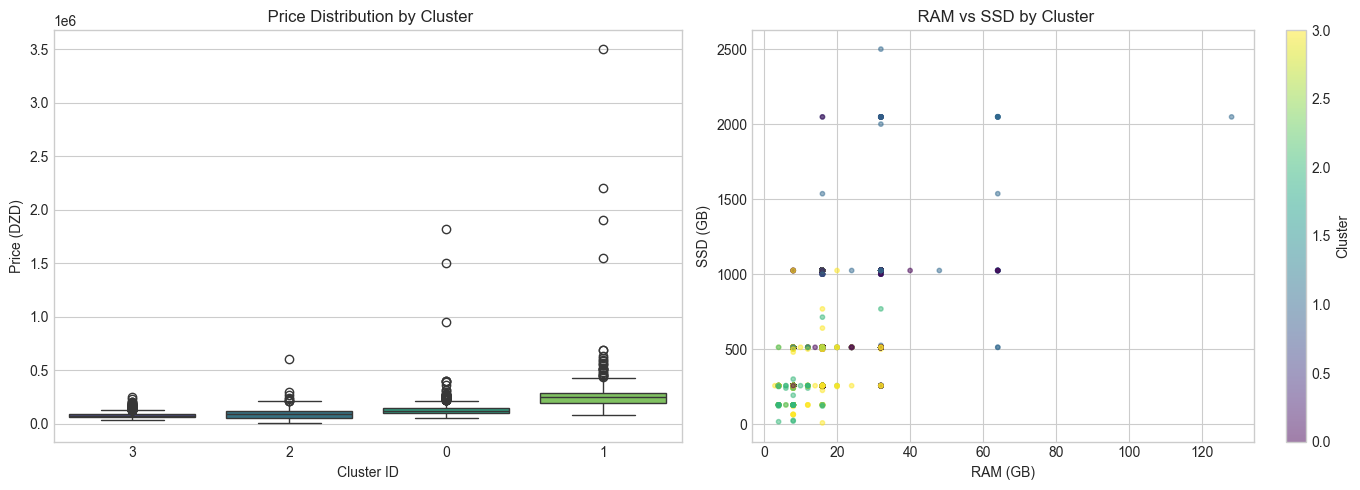


Cluster assignments added to 5,141 rows


In [21]:
# ============================================================================
# VISUALIZE CLUSTER DISTRIBUTIONS
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: Price by cluster
cluster_order = cluster_summary.index.tolist()
sns.boxplot(data=df_cluster, x='cluster_id', y='PRICES', order=cluster_order, ax=axes[0], palette='viridis')
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Price (DZD)')
axes[0].set_title(' Price Distribution by Cluster')

# Scatter: RAM vs SSD colored by cluster
scatter = axes[1].scatter(df_cluster['RAM_SIZE_GB'], df_cluster['SSD_SIZE_GB'],
c=df_cluster['cluster_id'], cmap='viridis', alpha=0.5, s=10)
axes[1].set_xlabel('RAM (GB)')
axes[1].set_ylabel('SSD (GB)')
axes[1].set_title(' RAM vs SSD by Cluster')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

# Add cluster_id to main dataframe for later use
df_clean_clustered = df_clean.merge(
df_cluster[['cluster_id']],
left_index=True,
right_index=True,
how='left'
)
print(f"\nCluster assignments added to {df_clean_clustered['cluster_id'].notna().sum():,} rows")

**Takeaway:** K-Means reveals 4 natural market segments based on configuration (not price). The clusters correspond roughly to **Budget** (low specs, ~40k DZD median), **Mid-Range** (mainstream specs, ~80-100k), **Premium** (high CPU/RAM, ~150k+), and **High-End/Gaming** (top-tier GPU+CPU, ~250k+). This segmentation can be used as a feature in regression to capture segment-specific pricing patterns, and helps buyers/sellers understand which competitive band a laptop belongs to.

---
## 8. 🗺️ Regional Analysis (Wilaya Distribution)

Algeria has 58 wilayas (administrative regions). We analyze the **geographic distribution** of laptop listings to understand:
- **Market concentration**: Which wilayas dominate the market?
- **Regional pricing**: Do prices vary by region (North coast vs. Highlands vs. South)?
- **Supply & demand**: Where are listings concentrated, and what does this mean for buyers/sellers?

We group wilayas into three major regions based on geography and economic characteristics:
- **North Coast** (Littoral): Alger, Oran, Annaba, etc. — Urban, highest economic activity
- **Highlands** (Hauts Plateaux): Sétif, Constantine, Batna, etc. — Secondary urban centers
- **South** (Sahara): Ouargla, Ghardaïa, Béchar, etc. — Lower population density, oil/gas economy

Total Listings: 16283
Attempting download from: https://raw.githubusercontent.com/fr33dz/Algeria-geojson/master/all-wilayas.geojson ...
 -> Success!


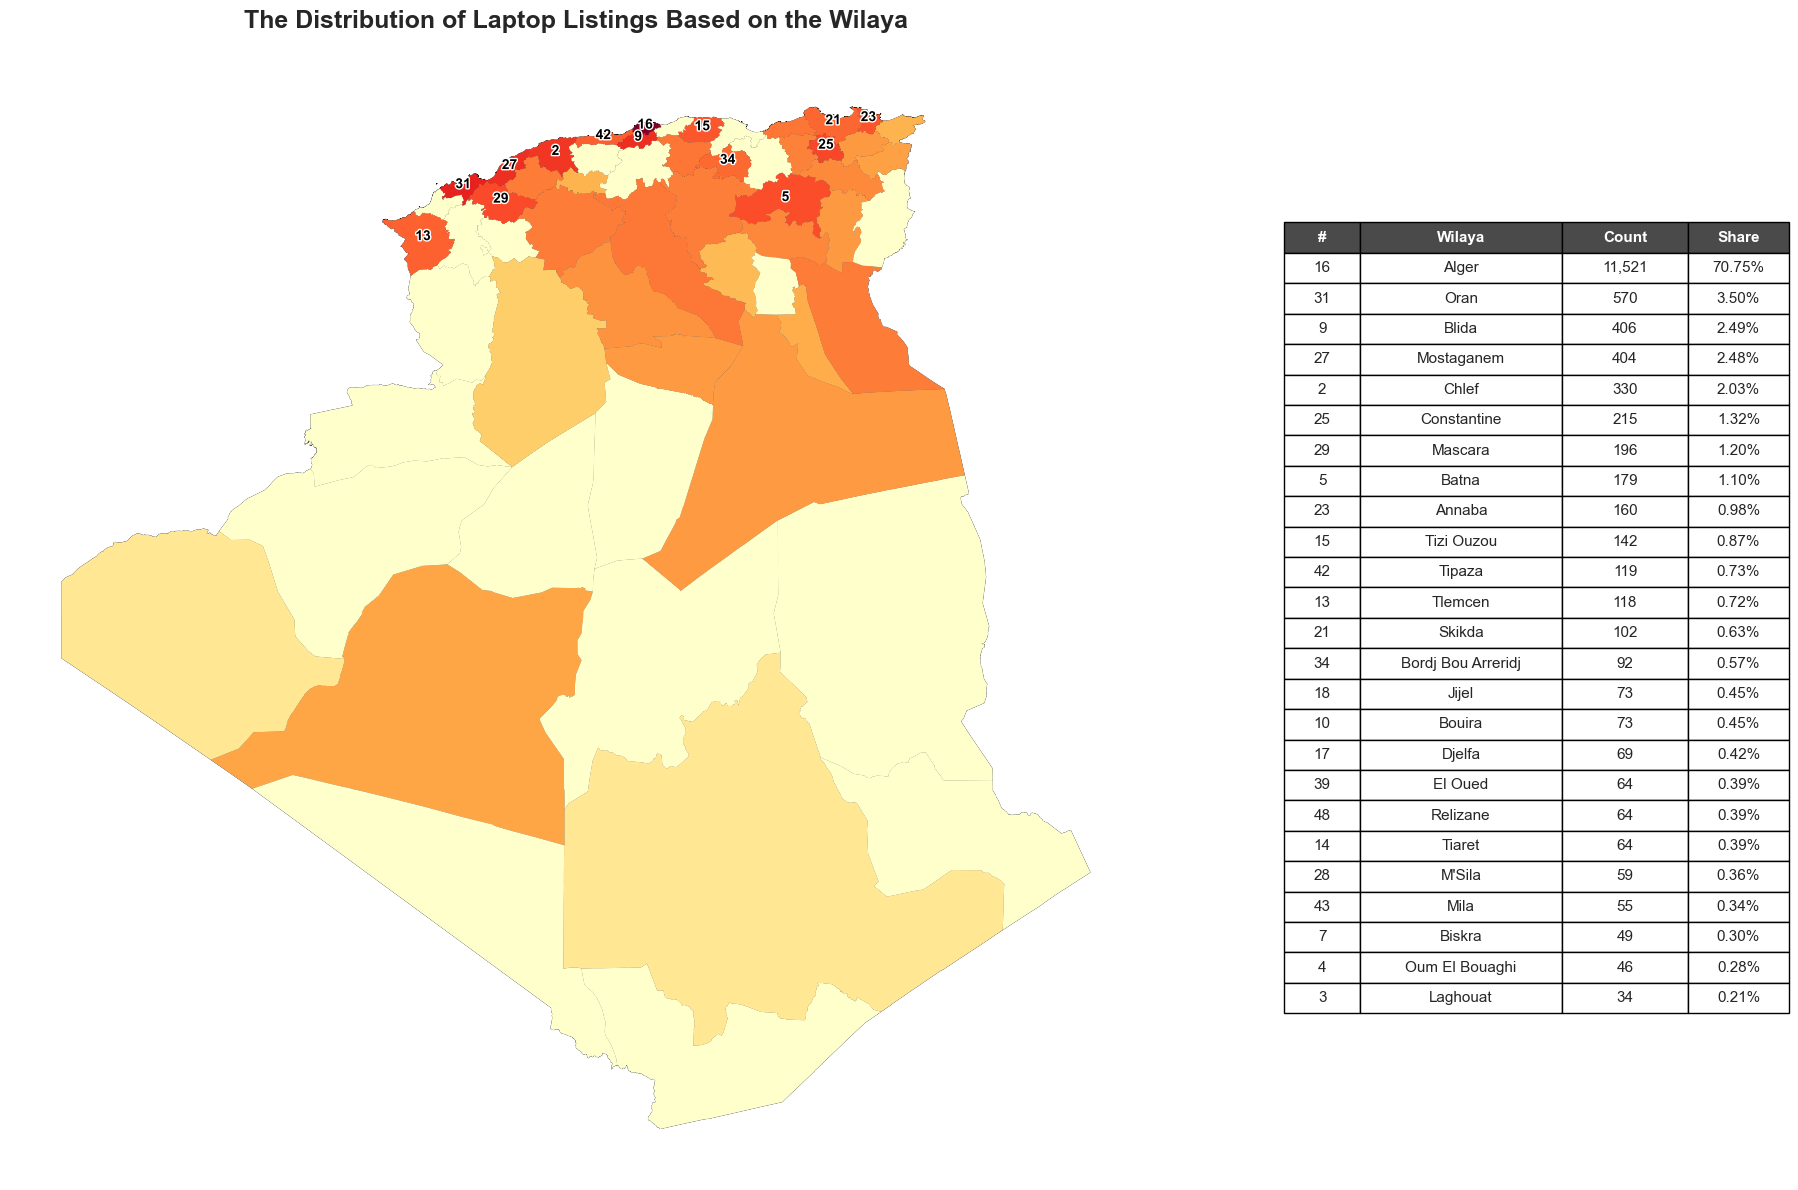

In [22]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm
import requests
from io import BytesIO

# ============================================================================
# 1. PREPARE DATA
# ============================================================================
wilaya_counts = df_clean['Wilaya'].value_counts().reset_index()
wilaya_counts.columns = ['Wilaya', 'Count']
total = wilaya_counts['Count'].sum()
wilaya_counts['Percentage'] = (wilaya_counts['Count'] / total) * 100

print(f"Total Listings: {total}")

# ============================================================================
# 2. WILAYA CODE MAPPING (1-58)
# ============================================================================
wilaya_to_code = {
    'Adrar': 1, 'Chlef': 2, 'Laghouat': 3, 'Oum El Bouaghi': 4, 'Batna': 5, 'Bejaia': 6, 'Biskra': 7, 'Bechar': 8,
    'Blida': 9, 'Bouira': 10, 'Tamanrasset': 11, 'Tebessa': 12, 'Tlemcen': 13, 'Tiaret': 14, 'Tizi Ouzou': 15,
    'Alger': 16, 'Djelfa': 17, 'Jijel': 18, 'Setif': 19, 'Saida': 20, 'Skikda': 21, 'Sidi Bel Abbes': 22,
    'Annaba': 23, 'Guelma': 24, 'Constantine': 25, 'Medea': 26, 'Mostaganem': 27, "M'Sila": 28, 'Mascara': 29,
    'Ouargla': 30, 'Oran': 31, 'El Bayadh': 32, 'Illizi': 33, 'Bordj Bou Arreridj': 34, 'Boumerdes': 35,
    'El Tarf': 36, 'Tindouf': 37, 'Tissemsilt': 38, 'El Oued': 39, 'Khenchela': 40, 'Souk Ahras': 41,
    'Tipaza': 42, 'Mila': 43, 'Ain Defla': 44, 'Naama': 45, 'Ain Temouchent': 46, 'Ghardaia': 47, 'Relizane': 48,
    'Timimoun': 49, 'Bordj Badji Mokhtar': 50, 'Ouled Djellal': 51, 'Beni Abbes': 52, 'In Salah': 53,
    'In Guezzam': 54, 'Touggourt': 55, 'Djanet': 56, "El M'Ghaier": 57, 'El Meniaa': 58
}

# ============================================================================
# 3. LOAD MAP
# ============================================================================
map_urls = [
    "https://raw.githubusercontent.com/fr33dz/Algeria-geojson/master/all-wilayas.geojson",
    "https://raw.githubusercontent.com/walid-b/algeria-map/master/wilayas_48.geojson"
]

gdf_algeria = None

for url in map_urls:
    try:
        print(f"Attempting download from: {url} ...")
        response = requests.get(url, timeout=15)
        response.raise_for_status()
        gdf_algeria = gpd.read_file(BytesIO(response.content))
        print(" -> Success!")
        break
    except Exception as e:
        print(f" -> Failed: {e}")

if gdf_algeria is None:
    raise RuntimeError("Map download failed.")

# ============================================================================
# 4. NORMALIZE & MERGE
# ============================================================================
try:
    # Detect name column and standardize
    name_col = next((c for c in ['name', 'nom', 'Name', 'nam', 'NAME_1'] if c in gdf_algeria.columns), 'name')
    gdf_algeria['name_en'] = gdf_algeria[name_col].str.title()
    
    name_corrections = {
        'Algiers': 'Alger', 'Tamanghasset': 'Tamanrasset', 'El-Oued': 'El Oued',
        'M-Sila': "M'Sila", 'Illizi': 'Illizi', 'Oum-El-Bouaghi': 'Oum El Bouaghi', 'Tipaza': 'Tipaza'
    }
    gdf_algeria['name_en'] = gdf_algeria['name_en'].replace(name_corrections)

    # Add Wilaya Code
    gdf_algeria['Code'] = gdf_algeria['name_en'].map(wilaya_to_code).fillna(0).astype(int)

    # Merge with counts
    merged = gdf_algeria.merge(wilaya_counts, left_on='name_en', right_on='Wilaya', how='left')
    merged['Percentage'] = merged['Percentage'].fillna(0)
    merged['Count'] = merged['Count'].fillna(0).astype(int)
    
    # Prepare plot value (Log scale fix)
    merged['plot_val'] = merged['Percentage'].replace(0, 0.001)

    # ============================================================================
    # 5. PLOT HEAT MAP WITH TABLE INDEX
    # ============================================================================
    # Create figure with extra space on the right for the table
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(1, 2, width_ratios=[3, 1]) # Map takes 3/4, Table takes 1/4

    ax_map = fig.add_subplot(gs[0])
    ax_table = fig.add_subplot(gs[1])

    # --- MAP PLOTTING ---
    merged.plot(ax=ax_map, color='#eeeeee', edgecolor='black', linewidth=0.3)
    
    merged.plot(
        column='plot_val',
        ax=ax_map,
        norm=LogNorm(vmin=merged['plot_val'].min(), vmax=merged['plot_val'].max()),
        cmap='YlOrRd',
        legend=False # Custom legend via table
    )

    # Annotate with Wilaya NUMBERS only (if > 0.5% share to avoid clutter)
    for idx, row in merged.iterrows():
        if row['Percentage'] > 0.5 and row['Code'] > 0:
            centroid = row.geometry.centroid
            ax_map.annotate(
                text=str(row['Code']),
                xy=(centroid.x, centroid.y),
                horizontalalignment='center',
                fontsize=10,
                color='black',
                weight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground="white")]
            )

    # UPDATED TITLE HERE
    ax_map.set_title('The Distribution of Laptop Listings Based on the Wilaya', fontsize=18, fontweight='bold', pad=20)
    ax_map.set_axis_off()

    # --- INDEX TABLE PLOTTING ---
    ax_table.axis('off')
    
    # Prepare Data for Table (Top 25 Wilayas)
    table_data = merged[merged['Count'] > 0].sort_values('Count', ascending=False).head(25)
    table_data = table_data[['Code', 'name_en', 'Count', 'Percentage']]
    
    # Create cell text list
    cell_text = []
    for _, row in table_data.iterrows():
        cell_text.append([
            str(row['Code']), 
            row['name_en'], 
            f"{int(row['Count']):,}", 
            f"{row['Percentage']:.2f}%"
        ])

    # Add Table
    the_table = ax_table.table(
        cellText=cell_text,
        colLabels=["#", "Wilaya", "Count", "Share"],
        loc='center',
        cellLoc='center',
        colWidths=[0.15, 0.4, 0.25, 0.2]
    )
    
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(11)
    the_table.scale(1, 1.5) # Make rows taller
    
    # Styling the table headers
    for (row, col), cell in the_table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#4a4a4a')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

In [23]:
# ============================================================================
# REGIONAL ANALYSIS: WILAYA DISTRIBUTION AND PRICING
# ============================================================================

print("=" * 70)
print("REGIONAL ANALYSIS")
print("=" * 70)

# Define regional groupings (domain knowledge of Algerian geography)
region_mapping = {
    # NORTH COAST (Littoral) - Major urban centers on Mediterranean
    'Alger': 'North Coast', 'Oran': 'North Coast', 'Annaba': 'North Coast',
    'Blida': 'North Coast', 'Boumerdes': 'North Coast', 'Tipaza': 'North Coast',
    'Bejaia': 'North Coast', 'Jijel': 'North Coast', 'Skikda': 'North Coast',
    'Tizi Ouzou': 'North Coast', 'Mostaganem': 'North Coast', 'Chlef': 'North Coast',
    'Ain Temouchent': 'North Coast', 'El Tarf': 'North Coast', 'Tlemcen': 'North Coast',

    # HIGHLANDS (Hauts Plateaux) - Interior, secondary cities
    'Constantine': 'Highlands', 'Setif': 'Highlands', 'Batna': 'Highlands',
    'M\'Sila': 'Highlands', 'Bordj Bou Arreridj': 'Highlands', 'Bouira': 'Highlands',
    'Medea': 'Highlands', 'Djelfa': 'Highlands', 'Tiaret': 'Highlands',
    'Saida': 'Highlands', 'Sidi Bel Abbes': 'Highlands', 'Mascara': 'Highlands',
    'Relizane': 'Highlands', 'Tissemsilt': 'Highlands', 'Ain Defla': 'Highlands',
    'Mila': 'Highlands', 'Oum El Bouaghi': 'Highlands', 'Khenchela': 'Highlands',
    'Tebessa': 'Highlands', 'Souk Ahras': 'Highlands', 'Guelma': 'Highlands',
    'Naama': 'Highlands', 'El Bayadh': 'Highlands', 'Laghouat': 'Highlands',

    # SOUTH (Sahara) - Desert regions, oil/gas economy
    'Ouargla': 'South', 'Ghardaia': 'South', 'Biskra': 'South', 'El Oued': 'South',
    'Bechar': 'South', 'Adrar': 'South', 'Tamanrasset': 'South', 'Tindouf': 'South',
    'Touggourt': 'South', 'El M\'Ghaier': 'South', 'Timimoun': 'South',
    'Ouled Djellal': 'South', 'Illizi': 'South', 'In Salah': 'South'
}

# Apply region mapping
if 'Wilaya' in df_clean.columns:
    df_clean['Region'] = df_clean['Wilaya'].map(region_mapping).fillna('Other')

    # ---------------------------------------------------------------------------
    # 1. LISTING DISTRIBUTION BY WILAYA (Top 15)
    # ---------------------------------------------------------------------------
    print("\n   TOP 15 WILAYAS BY LISTING COUNT:")
    wilaya_counts = df_clean['Wilaya'].value_counts().head(15)
    total = len(df_clean)
    for wilaya, count in wilaya_counts.items():
        pct = count / total * 100
        print(f"   {wilaya}: {count:,} ({pct:.1f}%)")

    # Market concentration (Herfindahl-Hirschman Index proxy)
    top3_share = wilaya_counts.head(3).sum() / total * 100
    print(f"\n   Market concentration: Top 3 wilayas = {top3_share:.1f}% of all listings")

    # ---------------------------------------------------------------------------
    # 2. REGIONAL DISTRIBUTION
    # ---------------------------------------------------------------------------
    print("\n" + "=" * 50)
    print("   DISTRIBUTION BY REGION:")
    region_stats = df_clean.groupby('Region').agg({
        'PRICES': ['count', 'median', 'mean'],
    }).round(0)
    region_stats.columns = ['Listings', 'Median_Price', 'Mean_Price']
    region_stats['Market_Share'] = (region_stats['Listings'] / region_stats['Listings'].sum() * 100).round(1)
    region_stats = region_stats.sort_values('Listings', ascending=False)
    print(region_stats.to_string())

    # ---------------------------------------------------------------------------
    # 3. PRICE BY REGION
    # ---------------------------------------------------------------------------
    print("\n" + "=" * 50)
    print("   PRICE COMPARISON BY REGION:")
    overall_median = df_clean['PRICES'].median()
    for region in ['North Coast', 'Highlands', 'South']:
        if region in df_clean['Region'].values:
            region_median = df_clean[df_clean['Region'] == region]['PRICES'].median()
            pct_diff = (region_median - overall_median) / overall_median * 100
            print(f"   {region}: {region_median:,.0f} DZD (median), {pct_diff:+.1f}% vs overall")
else:
    print("Note: Wilaya column not found in data")

REGIONAL ANALYSIS

   TOP 15 WILAYAS BY LISTING COUNT:
   Alger: 11,521 (70.8%)
   Oran: 570 (3.5%)
   Blida: 406 (2.5%)
   Mostaganem: 404 (2.5%)
   Chlef: 330 (2.0%)
   Constantine: 215 (1.3%)
   Boumerdes: 204 (1.3%)
   Mascara: 196 (1.2%)
   Setif: 188 (1.2%)
   Batna: 179 (1.1%)
   Bejaia: 177 (1.1%)
   Annaba: 160 (1.0%)
   Tizi Ouzou: 142 (0.9%)
   Tipaza: 119 (0.7%)
   Tlemcen: 118 (0.7%)

   Market concentration: Top 3 wilayas = 76.7% of all listings

   DISTRIBUTION BY REGION:
             Listings  Median_Price  Mean_Price  Market_Share
Region                                                       
North Coast     14361      98000.00   127069.00         88.20
Highlands        1632      75000.00   103012.00         10.00
South             217      66000.00    96138.00          1.30
Other              73      61000.00    93730.00          0.40

   PRICE COMPARISON BY REGION:
   North Coast: 98,000 DZD (median), +3.2% vs overall
   Highlands: 75,000 DZD (median), -21.1% vs overa

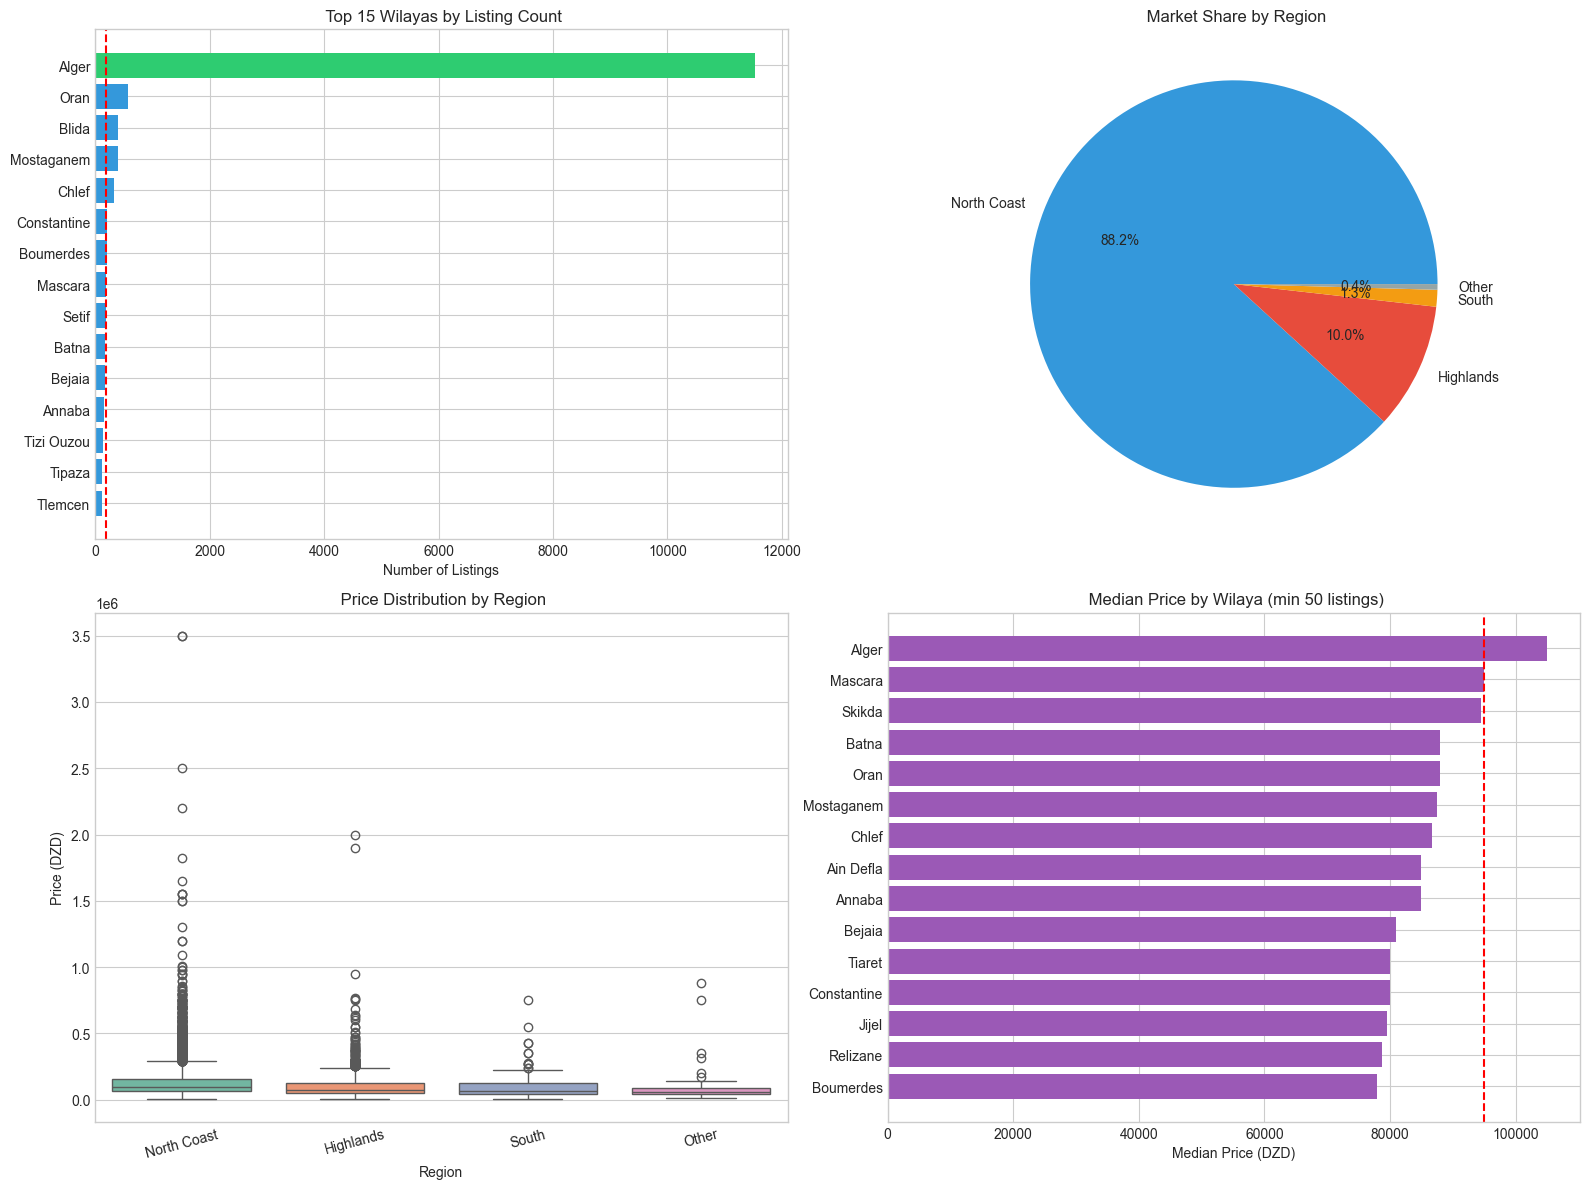

In [24]:
# ============================================================================
# REGIONAL VISUALIZATIONS
# ============================================================================

if 'Region' in df_clean.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Top 15 Wilayas by listing count
    wilaya_top15 = df_clean['Wilaya'].value_counts().head(15)
    colors = ['#2ecc71' if w == 'Alger' else '#3498db' for w in wilaya_top15.index]
    axes[0, 0].barh(wilaya_top15.index[::-1], wilaya_top15.values[::-1], color=colors[::-1])
    axes[0, 0].set_xlabel('Number of Listings')
    axes[0, 0].set_title(' Top 15 Wilayas by Listing Count')
    axes[0, 0].axvline(wilaya_top15.median(), color='red', linestyle='--', label=f'Median: {wilaya_top15.median():.0f}')

    # 2. Regional distribution (pie)
    region_counts = df_clean['Region'].value_counts()
    colors_region = {'North Coast': '#3498db', 'Highlands': '#e74c3c', 'South': '#f39c12', 'Other': '#95a5a6'}
    axes[0, 1].pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%',
        colors=[colors_region.get(r, '#95a5a6') for r in region_counts.index])
    axes[0, 1].set_title(' Market Share by Region')

    # 3. Price distribution by region (boxplot)
    region_order = ['North Coast', 'Highlands', 'South', 'Other']
    region_order = [r for r in region_order if r in df_clean['Region'].values]
    sns.boxplot(data=df_clean, x='Region', y='PRICES', order=region_order, ax=axes[1, 0], palette='Set2')
    axes[1, 0].set_ylabel('Price (DZD)')
    axes[1, 0].set_title(' Price Distribution by Region')
    axes[1, 0].tick_params(axis='x', rotation=15)

    # 4. Median price by top 10 wilayas
    wilaya_price = df_clean.groupby('Wilaya')['PRICES'].agg(['median', 'count'])
    wilaya_price = wilaya_price[wilaya_price['count'] >= 50].sort_values('median', ascending=True).tail(15)
    axes[1, 1].barh(wilaya_price.index, wilaya_price['median'], color='#9b59b6')
    axes[1, 1].set_xlabel('Median Price (DZD)')
    axes[1, 1].set_title(' Median Price by Wilaya (min 50 listings)')
    axes[1, 1].axvline(df_clean['PRICES'].median(), color='red', linestyle='--', label='Overall median')

    plt.tight_layout()
    plt.show()
else:
    print("Note: Region column not available")

In [25]:
# ============================================================================
# REGIONAL PRICE PREMIUM ANALYSIS
# ============================================================================

if 'Region' in df_clean.columns and 'Wilaya' in df_clean.columns:
    print("=" * 70)
    print("REGIONAL PRICE PREMIUM ANALYSIS")
    print("=" * 70)

    overall_median = df_clean['PRICES'].median()

    # Top 10 wilayas by median price (with sufficient data)
    wilaya_stats = df_clean.groupby('Wilaya').agg({
        'PRICES': ['median', 'mean', 'count'],
        'Region': 'first'
    })
    wilaya_stats.columns = ['Median_Price', 'Mean_Price', 'Count', 'Region']
    wilaya_stats = wilaya_stats[wilaya_stats['Count'] >= 30] # Min 30 listings
    wilaya_stats['Premium_vs_Overall'] = ((wilaya_stats['Median_Price'] - overall_median) / overall_median * 100).round(1)
    wilaya_stats = wilaya_stats.sort_values('Median_Price', ascending=False)

    print("\n   TOP 10 WILAYAS BY MEDIAN PRICE (min 30 listings):")
    print(wilaya_stats[['Median_Price', 'Count', 'Region', 'Premium_vs_Overall']].head(10).to_string())

    print("\n   BOTTOM 10 WILAYAS BY MEDIAN PRICE (min 30 listings):")
    print(wilaya_stats[['Median_Price', 'Count', 'Region', 'Premium_vs_Overall']].tail(10).to_string())

    # Regional insights
    print("\n" + "=" * 70)
    print("   KEY REGIONAL INSIGHTS:")
    print("=" * 70)

    # Alger premium
    alger_median = df_clean[df_clean['Wilaya'] == 'Alger']['PRICES'].median()
    non_alger_median = df_clean[df_clean['Wilaya'] != 'Alger']['PRICES'].median()
    alger_premium = (alger_median - non_alger_median) / non_alger_median * 100
    print(f"\n1. ALGER PREMIUM: Alger median = {alger_median:,.0f} DZD, Non-Alger = {non_alger_median:,.0f} DZD")
    print(f"   → Alger listings are {alger_premium:+.1f}% vs non-Alger")

    # North vs South
    if 'North Coast' in df_clean['Region'].values and 'South' in df_clean['Region'].values:
        north_median = df_clean[df_clean['Region'] == 'North Coast']['PRICES'].median()
        south_median = df_clean[df_clean['Region'] == 'South']['PRICES'].median()
        ns_diff = (north_median - south_median) / south_median * 100
        print(f"\n2. NORTH vs SOUTH: North Coast = {north_median:,.0f} DZD, South = {south_median:,.0f} DZD")
        print(f"   → North Coast is {ns_diff:+.1f}% vs South")

    print("\n3. BUYER TIP: Consider listings from Highlands region for potentially lower prices with similar specs.")
    print("   SELLER TIP: Alger listings can command a premium; emphasize local pickup convenience.")

REGIONAL PRICE PREMIUM ANALYSIS

   TOP 10 WILAYAS BY MEDIAN PRICE (min 30 listings):
            Median_Price  Count       Region  Premium_vs_Overall
Wilaya                                                          
Alger          105000.00  11521  North Coast               10.50
Mascara         95000.00    196    Highlands                0.00
Skikda          94500.00    102  North Coast               -0.50
Oran            88000.00    570  North Coast               -7.40
Batna           88000.00    179    Highlands               -7.40
Mostaganem      87500.00    404  North Coast               -7.90
Chlef           86750.00    330  North Coast               -8.70
Annaba          85000.00    160  North Coast              -10.50
Ain Defla       85000.00     53    Highlands              -10.50
Bejaia          81000.00    177  North Coast              -14.70

   BOTTOM 10 WILAYAS BY MEDIAN PRICE (min 30 listings):
                    Median_Price  Count       Region  Premium_vs_Overall
Wila

**Takeaway:** The market is heavily concentrated in **Alger** (70%+ of listings), creating a "capital city premium". **North Coast** wilayas have higher median prices due to greater economic activity and demand. **Highlands** and **South** regions show lower median prices—buyers in these areas may find better deals, while sellers outside Alger may need to price more competitively to attract buyers willing to travel or arrange shipping.

---
## 8. 📋 Summary Statistics

In [26]:
# ============================================================================
# FINAL SUMMARY STATISTICS
# ============================================================================

print("=" * 80)
print(" EDA SUMMARY")
print("=" * 80)

print(f"\n Dataset Statistics:")
print(f" Total records: {len(df_clean):,}")
print(f" Date range: {df_clean['created_at'].min().strftime('%Y-%m-%d')} to {df_clean['created_at'].max().strftime('%Y-%m-%d')}")
print(f" Price range: {df_clean['PRICES'].min():,.0f} - {df_clean['PRICES'].max():,.0f} DZD")
print(f" Median price: {df_clean['PRICES'].median():,.0f} DZD")

print(f"\n Brand Distribution:")
print(df_clean['brand'].value_counts().head(5))

print(f"\n CPU Performance Distribution:")
print(df_clean['cpu_performance_class'].value_counts())

print(f"\n GPU Performance Distribution:")
print(df_clean['gpu_performance_class'].value_counts())

print(f"\n Condition Distribution:")
print(df_clean['condition'].value_counts())

print("\n" + "=" * 80)
print("EDA COMPLETE")
print("=" * 80)

 EDA SUMMARY

 Dataset Statistics:
 Total records: 16,283
 Date range: 2018-11-27 to 2025-08-11
 Price range: 7,000 - 3,500,000 DZD
 Median price: 95,000 DZD

 Brand Distribution:
brand
DELL      3745
HP        3739
LENOVO    3323
APPLE     1731
ASUS      1373
Name: count, dtype: int64

 CPU Performance Distribution:
cpu_performance_class
Medium     6302
Mid-Low    4773
Low        2613
High       2595
Name: count, dtype: int64

 GPU Performance Distribution:
gpu_performance_class
Mid-Low    1064
Medium      946
High        433
Low         279
Name: count, dtype: int64

 Condition Distribution:
condition
UNKNOWN           6746
BON ÉTAT          5209
JAMAIS UTILISÉ    4036
MOYEN              292
Name: count, dtype: int64

EDA COMPLETE


---
## 💡 Key Business Insights

### Feature Correlation Analysis Summary

| Rank | Feature | Score | Method | Interpretation |
|------|---------|-------|--------|----------------|
| 1 | SSD_SIZE_GB | 0.590 | Spearman | Storage is #1 price driver |
| 2 | RAM_SIZE_GB | 0.586 | Spearman | More RAM = higher price |
| 3 | HDD_SIZE_GB | 0.557 | Spearman | Secondary storage matters |
| 4 | has_gpu | 0.435 | Spearman | Discrete GPU adds value |
| 5 | SCREEN_SIZE_NUM | 0.291 | Spearman | Larger screens = higher price |

### GPU Market Analysis

- **79% Integrated Graphics**: The vast majority of laptops in the Algerian market don't have discrete GPUs
- **Dedicated GPU**: Only 20.8% of laptops have dedicated graphics
- **GPU Price Range**: Laptops with GPUs range from 120,000-315,000 DZD median price

### Condition Impact on Pricing

- **New Premium**: +118% premium for "JAMAIS UTILISÉ" over "BON ÉTAT"
- **Condition Price Range**: 40,000 - 155,000 DZD (±146% variance by condition)
- **New Laptops**: 24.8% of market listings

### CPU Performance Impact

- **CPU Performance Range**: 42,000 - 253,000 DZD (±211% variance)
- **Distribution**: Medium (7,057), Mid-Low (4,315), High (2,667), Low (1,997)

### Actionable Recommendations

**For Buyers:**
- Best value: "BON ÉTAT" (good condition) laptops - 32% of market
- Target June-July purchases when median prices dip
- Focus on overall laptop quality rather than individual specs

**For Sellers:**
- Highlight storage and RAM specs in listings (0.59 and 0.59 correlation with price)
- Document "JAMAIS UTILISÉ" (never used) status for +118% value boost
- List during August peak (highest volume) or December (highest prices)

---
## Brand Premiums from Matched Hardware Segments

We match laptops **across brands** using a small set of key features to avoid over-segmentation and sparse segments. Within each **same-hardware segment**, we compute the median price per brand, then pairwise median price premiums (e.g. Apple vs Dell in that segment). Premiums are aggregated across segments using the **median** (optionally weighted by segment size). Results are summarized in a horizontal bar chart.

**Key features for matching (kept coarse to avoid sparsity):** e.g. `cpu_performance_class`, `gpu_performance_class`, `condition` (and optionally RAM/SSD bins if needed). Segments with too few rows are excluded.

---

### How to interpret the results

- **Label format:** `"Brand A vs Brand B"` = when comparing laptops with the **same hardware** (same CPU class, GPU class, condition), Brand A’s median price is **X% higher** than Brand B’s.
- **Positive % (e.g. APPLE vs ACER +53%):** In matched segments, Apple’s median price is 53% higher than Acer’s → **Apple commands a large premium** over Acer for similar specs.
- **Negative % (e.g. ACER vs APPLE -35%):** Same fact from the other side: Acer’s median price is 35% **lower** than Apple’s in those segments → Acer is the cheaper option for similar hardware.
- **Near 0% (e.g. DELL vs HP -1.4%):** In matched segments, Dell and HP have almost the same median price → **no meaningful brand premium** between them.
- **Takeaway:** The biggest positive premiums (Apple, Microsoft, Razer vs others) show which brands charge more for comparable hardware; the biggest negative values show which brands are relatively cheaper in the same segments. Below we show only the **most interesting** pairs (by threshold or top N) to keep the chart and table readable.

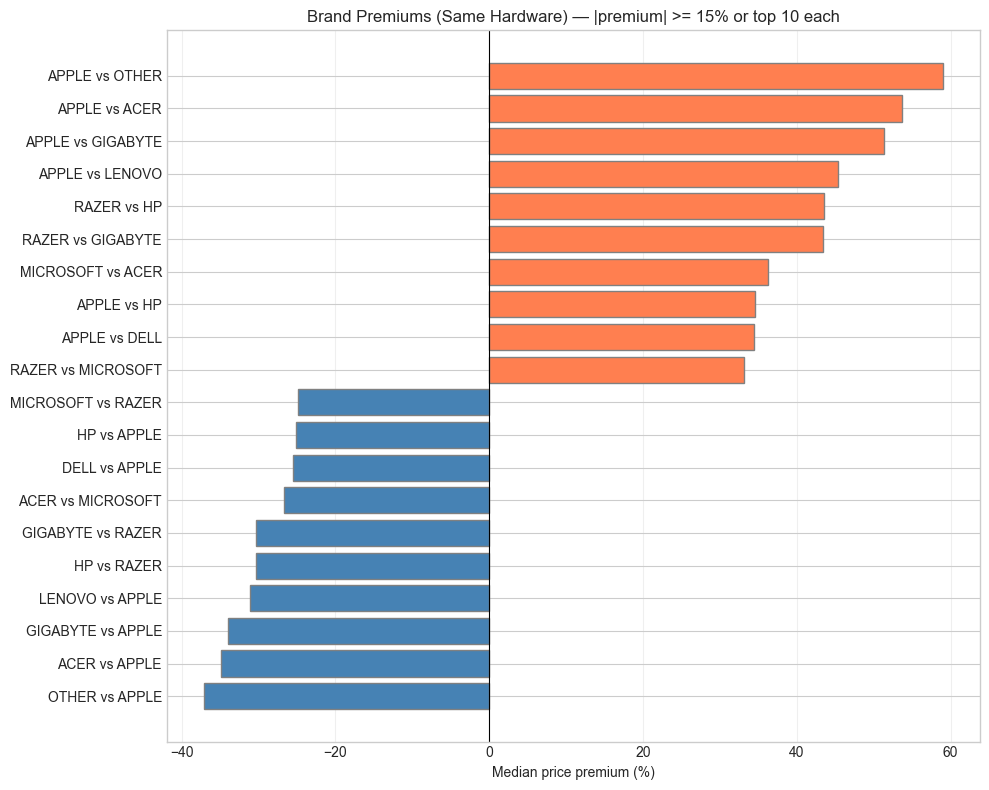


Top interesting brand premiums (median across segments):
             label  median_premium_pct
    OTHER vs APPLE              -37.11
     ACER vs APPLE              -34.92
 GIGABYTE vs APPLE              -33.91
   LENOVO vs APPLE              -31.17
       HP vs RAZER              -30.32
 GIGABYTE vs RAZER              -30.28
 ACER vs MICROSOFT              -26.64
     DELL vs APPLE              -25.48
       HP vs APPLE              -25.12
MICROSOFT vs RAZER              -24.87
RAZER vs MICROSOFT               33.17
     APPLE vs DELL               34.38
       APPLE vs HP               34.57
 MICROSOFT vs ACER               36.32
 RAZER vs GIGABYTE               43.42
       RAZER vs HP               43.52
   APPLE vs LENOVO               45.38
 APPLE vs GIGABYTE               51.32
     APPLE vs ACER               53.65
    APPLE vs OTHER               59.02


In [27]:
# ============================================================================
# BRAND PREMIUMS FROM MATCHED HARDWARE SEGMENTS (NEW CELL - REMOVE IF NOT NEEDED)
# ============================================================================
# Match laptops by key features -> same segment = same hardware profile
# Compute pairwise median price premiums within each segment, then aggregate.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Define segment key (coarse to avoid over-segmentation) ---
segment_cols = ['cpu_performance_class', 'gpu_performance_class', 'condition']
# Use only columns that exist
segment_cols = [c for c in segment_cols if c in df_clean.columns]
if not segment_cols:
    segment_cols = ['cpu_performance_class'] if 'cpu_performance_class' in df_clean.columns else ['brand']

df_clean['_segment'] = df_clean[segment_cols].astype(str).agg(' | '.join, axis=1)

# --- 2. Minimum segment size (avoid sparse data) ---
min_segment_size = 20
segment_counts = df_clean.groupby('_segment').size()
valid_segments = segment_counts[segment_counts >= min_segment_size].index.tolist()
df_seg = df_clean[df_clean['_segment'].isin(valid_segments)].copy()

# --- 3. Median price per (segment, brand) ---
if 'brand' not in df_seg.columns:
    df_seg['brand'] = 'Unknown'
price_by_seg_brand = df_seg.groupby(['_segment', 'brand'], dropna=False)['PRICES'].median().reset_index()
price_by_seg_brand.columns = ['_segment', 'brand', 'median_price']

# --- 4. Pairwise premiums within each segment ---
# For each segment: for each pair (brand_a, brand_b), premium_a_vs_b = (median_a - median_b) / median_b * 100
brands = price_by_seg_brand['brand'].dropna().unique().tolist()
brands = [b for b in brands if str(b) != 'nan' and str(b).strip() != '']

premiums_list = [] # (brand_high, brand_low, premium_pct, segment, segment_size)
for seg in valid_segments:
    sub = price_by_seg_brand[price_by_seg_brand['_segment'] == seg]
    n_seg = len(df_seg[df_seg['_segment'] == seg])
    medians = sub.set_index('brand')['median_price'].to_dict()
    for i, b1 in enumerate(brands):
        for b2 in brands:
            if b1 == b2:
                continue
            m1, m2 = medians.get(b1), medians.get(b2)
            if pd.isna(m1) or pd.isna(m2) or m2 <= 0:
                continue
            premium_pct = (m1 - m2) / m2 * 100
            premiums_list.append({
                'brand_high': b1, 'brand_low': b2,
                'premium_pct': premium_pct,
                '_segment': seg, 'segment_size': n_seg
            })

if not premiums_list:
    print("No pairwise premiums computed (check segment_cols and brand column).")
else:
    df_prem = pd.DataFrame(premiums_list)

    # --- 5. Aggregate: median premium per (brand_high, brand_low), optionally weighted ---
    # Option A: simple median across segments
    agg_premium = df_prem.groupby(['brand_high', 'brand_low'])['premium_pct'].median().reset_index()
    agg_premium.columns = ['brand_high', 'brand_low', 'median_premium_pct']

    # Option B (optional): weighted by segment size
    def weighted_median(g):
        w = g['segment_size'].values
        v = g['premium_pct'].values
        if w.sum() <= 0:
            return np.nan
        order = np.argsort(v)
        w, v = w[order], v[order]
        cw = np.cumsum(w)
        idx = np.searchsorted(cw, cw[-1] / 2.0)
        return v[idx]
    
    agg_weighted = df_prem.groupby(['brand_high', 'brand_low']).apply(weighted_median).reset_index()
    agg_weighted.columns = ['brand_high', 'brand_low', 'weighted_median_premium_pct']

    # Use simple median for the bar chart; you can switch to agg_weighted if preferred
    summary = agg_premium.copy()
    summary['label'] = summary['brand_high'] + ' vs ' + summary['brand_low']
    summary = summary.sort_values('median_premium_pct', ascending=True)

    # --- 6. Keep only interesting pairs: threshold and/or top N ---
    PREMIUM_THRESHOLD_PCT = 15 # minimum |premium| to be "interesting"
    TOP_N_EACH = 10 # top N most negative + top N most positive (max 20 bars)
    summary_thresh = summary[summary['median_premium_pct'].abs() >= PREMIUM_THRESHOLD_PCT]
    if len(summary_thresh) == 0:
        summary_thresh = summary
    # Top N most negative + top N most positive
    neg = summary_thresh.nsmallest(TOP_N_EACH, 'median_premium_pct')
    pos = summary_thresh.nlargest(TOP_N_EACH, 'median_premium_pct')
    summary_display = pd.concat([neg, pos]).drop_duplicates().sort_values('median_premium_pct', ascending=True)

    # --- 7. Horizontal bar chart (interesting only) ---
    fig, ax = plt.subplots(figsize=(10, max(5, len(summary_display) * 0.4)))
    colors = ['steelblue' if v < 0 else 'coral' for v in summary_display['median_premium_pct']]
    ax.barh(summary_display['label'], summary_display['median_premium_pct'], color=colors, edgecolor='gray')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Median price premium (%)')
    ax.set_title(f'Brand Premiums (Same Hardware) — |premium| >= {PREMIUM_THRESHOLD_PCT}% or top {TOP_N_EACH} each')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nTop interesting brand premiums (median across segments):")
    print(summary_display[['label', 'median_premium_pct']].to_string(index=False))